In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import lime
import lime.lime_tabular
from datetime import datetime
from pathlib import Path
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')

# Academic publication style settings
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.4)
sns.set_palette("deep")

# Configure matplotlib for publication quality
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print("✅ Libraries loaded successfully!")
print("✅ Academic publication style configured")

✅ Libraries loaded successfully!
✅ Academic publication style configured


In [18]:
# Set paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_DIR = PROJECT_ROOT / "ml" / "features"
MODELS_DIR = PROJECT_ROOT / "ml" / "models" / "saved" / "enhanced"
RESULTS_DIR = PROJECT_ROOT / "results" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

# Create directories
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Configuration - Top models per target as specified
TOP_MODELS = {
    'valence': 'XGBoost_tuned',
    'energy': 'XGBoost_tuned',
    'danceability': 'XGBoost_tuned',
    'popularity': 'CatBoost_tuned'
}

TARGETS = list(TOP_MODELS.keys())

print(f"📂 Project root: {PROJECT_ROOT}")
print(f"🎯 Targets and their top models:")
for target, model in TOP_MODELS.items():
    print(f"   - {target:12s}: {model}")

📂 Project root: /home/esstee/documents/bitirme
🎯 Targets and their top models:
   - valence     : XGBoost_tuned
   - energy      : XGBoost_tuned
   - danceability: XGBoost_tuned
   - popularity  : CatBoost_tuned


---
## 📋 Load Feature Names

In [19]:
def load_feature_names():
    """Load feature names from metadata"""
    metadata_path = FEATURES_DIR / "preprocessing_metadata.json"
    
    if metadata_path.exists():
        import json
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)
        
        feature_names = []
        
        # Audio features (21)
        if 'audio_feature_names' in metadata:
            feature_names.extend(metadata['audio_feature_names'])
        else:
            # Load from file
            audio_names_path = FEATURES_DIR / "audio_feature_names.txt"
            if audio_names_path.exists():
                with open(audio_names_path, 'r') as f:
                    feature_names.extend([line.strip() for line in f 
                                        if line.strip() and not line.strip().startswith('#')])
            else:
                feature_names.extend([f'audio_{i}' for i in range(21)])
        
        # Text stats (5)
        text_stats = ['word_count', 'unique_word_count', 'unique_ratio', 'avg_word_length', 'char_count']
        feature_names.extend(text_stats)
        
        # Sentiment (2)
        sentiment = ['sentiment_polarity', 'sentiment_subjectivity']
        feature_names.extend(sentiment)
        
        # Embeddings (384)
        embedding_names = [f'emb_{i}' for i in range(384)]
        feature_names.extend(embedding_names)
        
        return feature_names
    else:
        # Generate default names
        print("⚠️ Metadata not found, generating default feature names")
        feature_names = []
        feature_names.extend([f'audio_{i}' for i in range(21)])
        feature_names.extend(['word_count', 'unique_word_count', 'unique_ratio', 'avg_word_length', 'char_count'])
        feature_names.extend(['sentiment_polarity', 'sentiment_subjectivity'])
        feature_names.extend([f'emb_{i}' for i in range(384)])
        return feature_names

feature_names = load_feature_names()
print(f"✅ Loaded {len(feature_names)} feature names")
print(f"\n📌 First 30 features:")
for i, name in enumerate(feature_names[:30]):
    print(f"   {i:3d}. {name}")

✅ Loaded 412 feature names

📌 First 30 features:
     0. acousticness
     1. instrumentalness
     2. liveness
     3. speechiness
     4. loudness
     5. tempo
     6. duration_ms
     7. year
     8. mode
     9. key_sin
    10. key_cos
    11. genre_Blues
    12. genre_Classical
    13. genre_Country
    14. genre_Electronic
    15. genre_Folk
    16. genre_Hip-Hop
    17. genre_Jazz
    18. genre_Pop
    19. genre_R&B
    20. genre_Rock
    21. word_count
    22. unique_word_count
    23. unique_ratio
    24. avg_word_length
    25. char_count
    26. sentiment_polarity
    27. sentiment_subjectivity
    28. emb_0
    29. emb_1


In [20]:
def load_validation_data():
    """Load validation features and targets from .npy files"""
    try:
        # Load feature components
        X_audio = np.load(FEATURES_DIR / "X_val_audio.npy")
        X_text_stats = np.load(FEATURES_DIR / "X_val_text_stats.npy")
        X_sentiment = np.load(FEATURES_DIR / "X_val_sentiment.npy")
        X_embeddings = np.load(FEATURES_DIR / "X_val_embeddings.npy")
        
        # Concatenate features
        X_val_arr = np.hstack([X_audio, X_text_stats, X_sentiment, X_embeddings])
        
        # Create DataFrame
        X_val = pd.DataFrame(X_val_arr, columns=feature_names)
        
        # Load targets
        y_val = pd.DataFrame({
            'valence': np.load(FEATURES_DIR / "y_val_valence.npy"),
            'energy': np.load(FEATURES_DIR / "y_val_energy.npy"),
            'danceability': np.load(FEATURES_DIR / "y_val_danceability.npy"),
            'popularity': np.load(FEATURES_DIR / "y_val_popularity.npy")
        })
        
        return X_val, y_val
    except Exception as e:
        print(f"❌ Error loading validation data: {e}")
        return None, None

X_val, y_val = load_validation_data()
if X_val is not None:
    print(f"✅ Loaded validation data: {X_val.shape}")
    print(f"🎯 Targets shape: {y_val.shape}")
else:
    print("❌ Failed to load validation data")

✅ Loaded validation data: (82187, 412)
🎯 Targets shape: (82187, 4)


---
## 🔧 Define Helper Functions

In [21]:
def get_feature_importance(model, model_name, feature_names):
    """Extract feature importance from a model"""
    
    importance = None
    method = None
    
    # Tree-based models with feature_importances_
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        method = 'feature_importances_'
    
    # MLPRegressor - use first layer weights
    elif hasattr(model, 'coefs_') and len(model.coefs_) > 0:
        # Sum absolute weights from input to first hidden layer
        first_layer_weights = model.coefs_[0]
        importance = np.abs(first_layer_weights).sum(axis=1)
        method = 'mlp_first_layer'
    
    # Linear models with coef_
    elif hasattr(model, 'coef_'):
        importance = np.abs(model.coef_)
        if importance.ndim > 1:
            importance = importance.mean(axis=0)
        method = 'coef_'
    
    if importance is not None:
        # Verify shape
        if len(importance) != len(feature_names):
            print(f"⚠️ Shape mismatch: {len(importance)} vs {len(feature_names)}")
            return None
        
        # Normalize
        if importance.sum() > 0:
            importance = importance / importance.sum()
        
        return pd.DataFrame({
            'feature': feature_names,
            'importance': importance,
            'method': method
        }).sort_values('importance', ascending=False)
    
    return None

def analyze_model_importance(target, model_name, feature_names):
    """Analyze feature importance for a specific model and target"""
    
    model_path = MODELS_DIR / f"{model_name}_{target}.pkl"
    
    if not model_path.exists():
        return None
    
    try:
        model = joblib.load(model_path)
        importance_df = get_feature_importance(model, model_name, feature_names)
        
        if importance_df is not None:
            importance_df['target'] = target
            importance_df['model'] = model_name
            return importance_df
        return None
            
    except Exception as e:
        print(f"❌ Error loading {model_name}: {e}")
        return None

print("✅ Helper functions defined")

✅ Helper functions defined


---
## 🚀 Extract Feature Importance from All Models

In [22]:
print("🔍 Extracting feature importance for top models...\n")

all_importance = []

for target, model_name in TOP_MODELS.items():
    print(f"🎯 {target.upper()} (Model: {model_name})")
    
    result = analyze_model_importance(target, model_name, feature_names)
    if result is not None:
        all_importance.append(result)
        top_feat = result.iloc[0]['feature']
        top_imp = result.iloc[0]['importance']
        print(f"   ✅ Success → Top feature: {top_feat} ({top_imp:.3f})")
    else:
        print(f"   ⚠️ Failed to load or analyze")

# Combine all results
if all_importance:
    all_importance_df = pd.concat(all_importance, ignore_index=True)
    print(f"\n✅ Extracted importance for {len(all_importance)} top models")
else:
    print("\n❌ No importance data extracted")

🔍 Extracting feature importance for top models...

🎯 VALENCE (Model: XGBoost_tuned)
   ✅ Success → Top feature: genre_Rock (0.043)
🎯 ENERGY (Model: XGBoost_tuned)
   ✅ Success → Top feature: loudness (0.217)
🎯 DANCEABILITY (Model: XGBoost_tuned)
   ✅ Success → Top feature: genre_Rock (0.310)
🎯 POPULARITY (Model: CatBoost_tuned)
   ✅ Success → Top feature: year (0.154)

✅ Extracted importance for 4 top models


In [23]:
# Save raw data
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
raw_path = RESULTS_DIR / f"feature_importance_raw_{timestamp}.csv"

print(f"📂 Saving to: {raw_path}")
print(f"📊 DataFrame shape: {all_importance_df.shape}")
print(f"📁 Directory exists: {RESULTS_DIR.exists()}")

all_importance_df.to_csv(raw_path, index=False)

# Verify file was saved
if raw_path.exists():
    file_size = raw_path.stat().st_size / 1024
    print(f"✅ Saved raw importance data: {raw_path.name} ({file_size:.1f} KB)")
else:
    print(f"❌ ERROR: File was not saved!")

📂 Saving to: /home/esstee/documents/bitirme/results/metrics/feature_importance_raw_20251223_140717.csv
📊 DataFrame shape: (1648, 5)
📁 Directory exists: True
✅ Saved raw importance data: feature_importance_raw_20251223_140717.csv (120.3 KB)


---
## 📊 Top 20 Features per Target

In [24]:
print("🏆 TOP 20 FEATURES PER TARGET (averaged across models)\n")

summary_data = []

for target in TARGETS:
    target_df = all_importance_df[all_importance_df['target'] == target]
    top20 = target_df.groupby('feature')['importance'].mean().nlargest(20)
    
    print(f"\n{'='*70}")
    print(f"🎯 {target.upper()}")
    print(f"{'='*70}")
    
    for i, (feat, imp) in enumerate(top20.items(), 1):
        print(f"   {i:2d}. {feat:<30s} {imp:.4f}")
        summary_data.append({
            'target': target,
            'rank': i,
            'feature': feat,
            'avg_importance': imp
        })

summary_df = pd.DataFrame(summary_data)
summary_path = RESULTS_DIR / f"feature_importance_summary_{timestamp}.csv"
summary_df.to_csv(summary_path, index=False)
print(f"\n💾 Saved summary: {summary_path.name}")

🏆 TOP 20 FEATURES PER TARGET (averaged across models)


🎯 VALENCE
    1. genre_Rock                     0.0431
    2. emb_163                        0.0253
    3. emb_16                         0.0225
    4. duration_ms                    0.0223
    5. year                           0.0206
    6. genre_Electronic               0.0185
    7. genre_Hip-Hop                  0.0184
    8. word_count                     0.0180
    9. acousticness                   0.0179
   10. genre_Folk                     0.0137
   11. genre_Blues                    0.0134
   12. speechiness                    0.0127
   13. char_count                     0.0124
   14. liveness                       0.0100
   15. emb_31                         0.0099
   16. genre_Classical                0.0096
   17. genre_Country                  0.0076
   18. loudness                       0.0074
   19. tempo                          0.0061
   20. genre_Jazz                     0.0061

🎯 ENERGY
    1. loudness         

---
## 📈 Visualization 1: Top 20 Features per Target

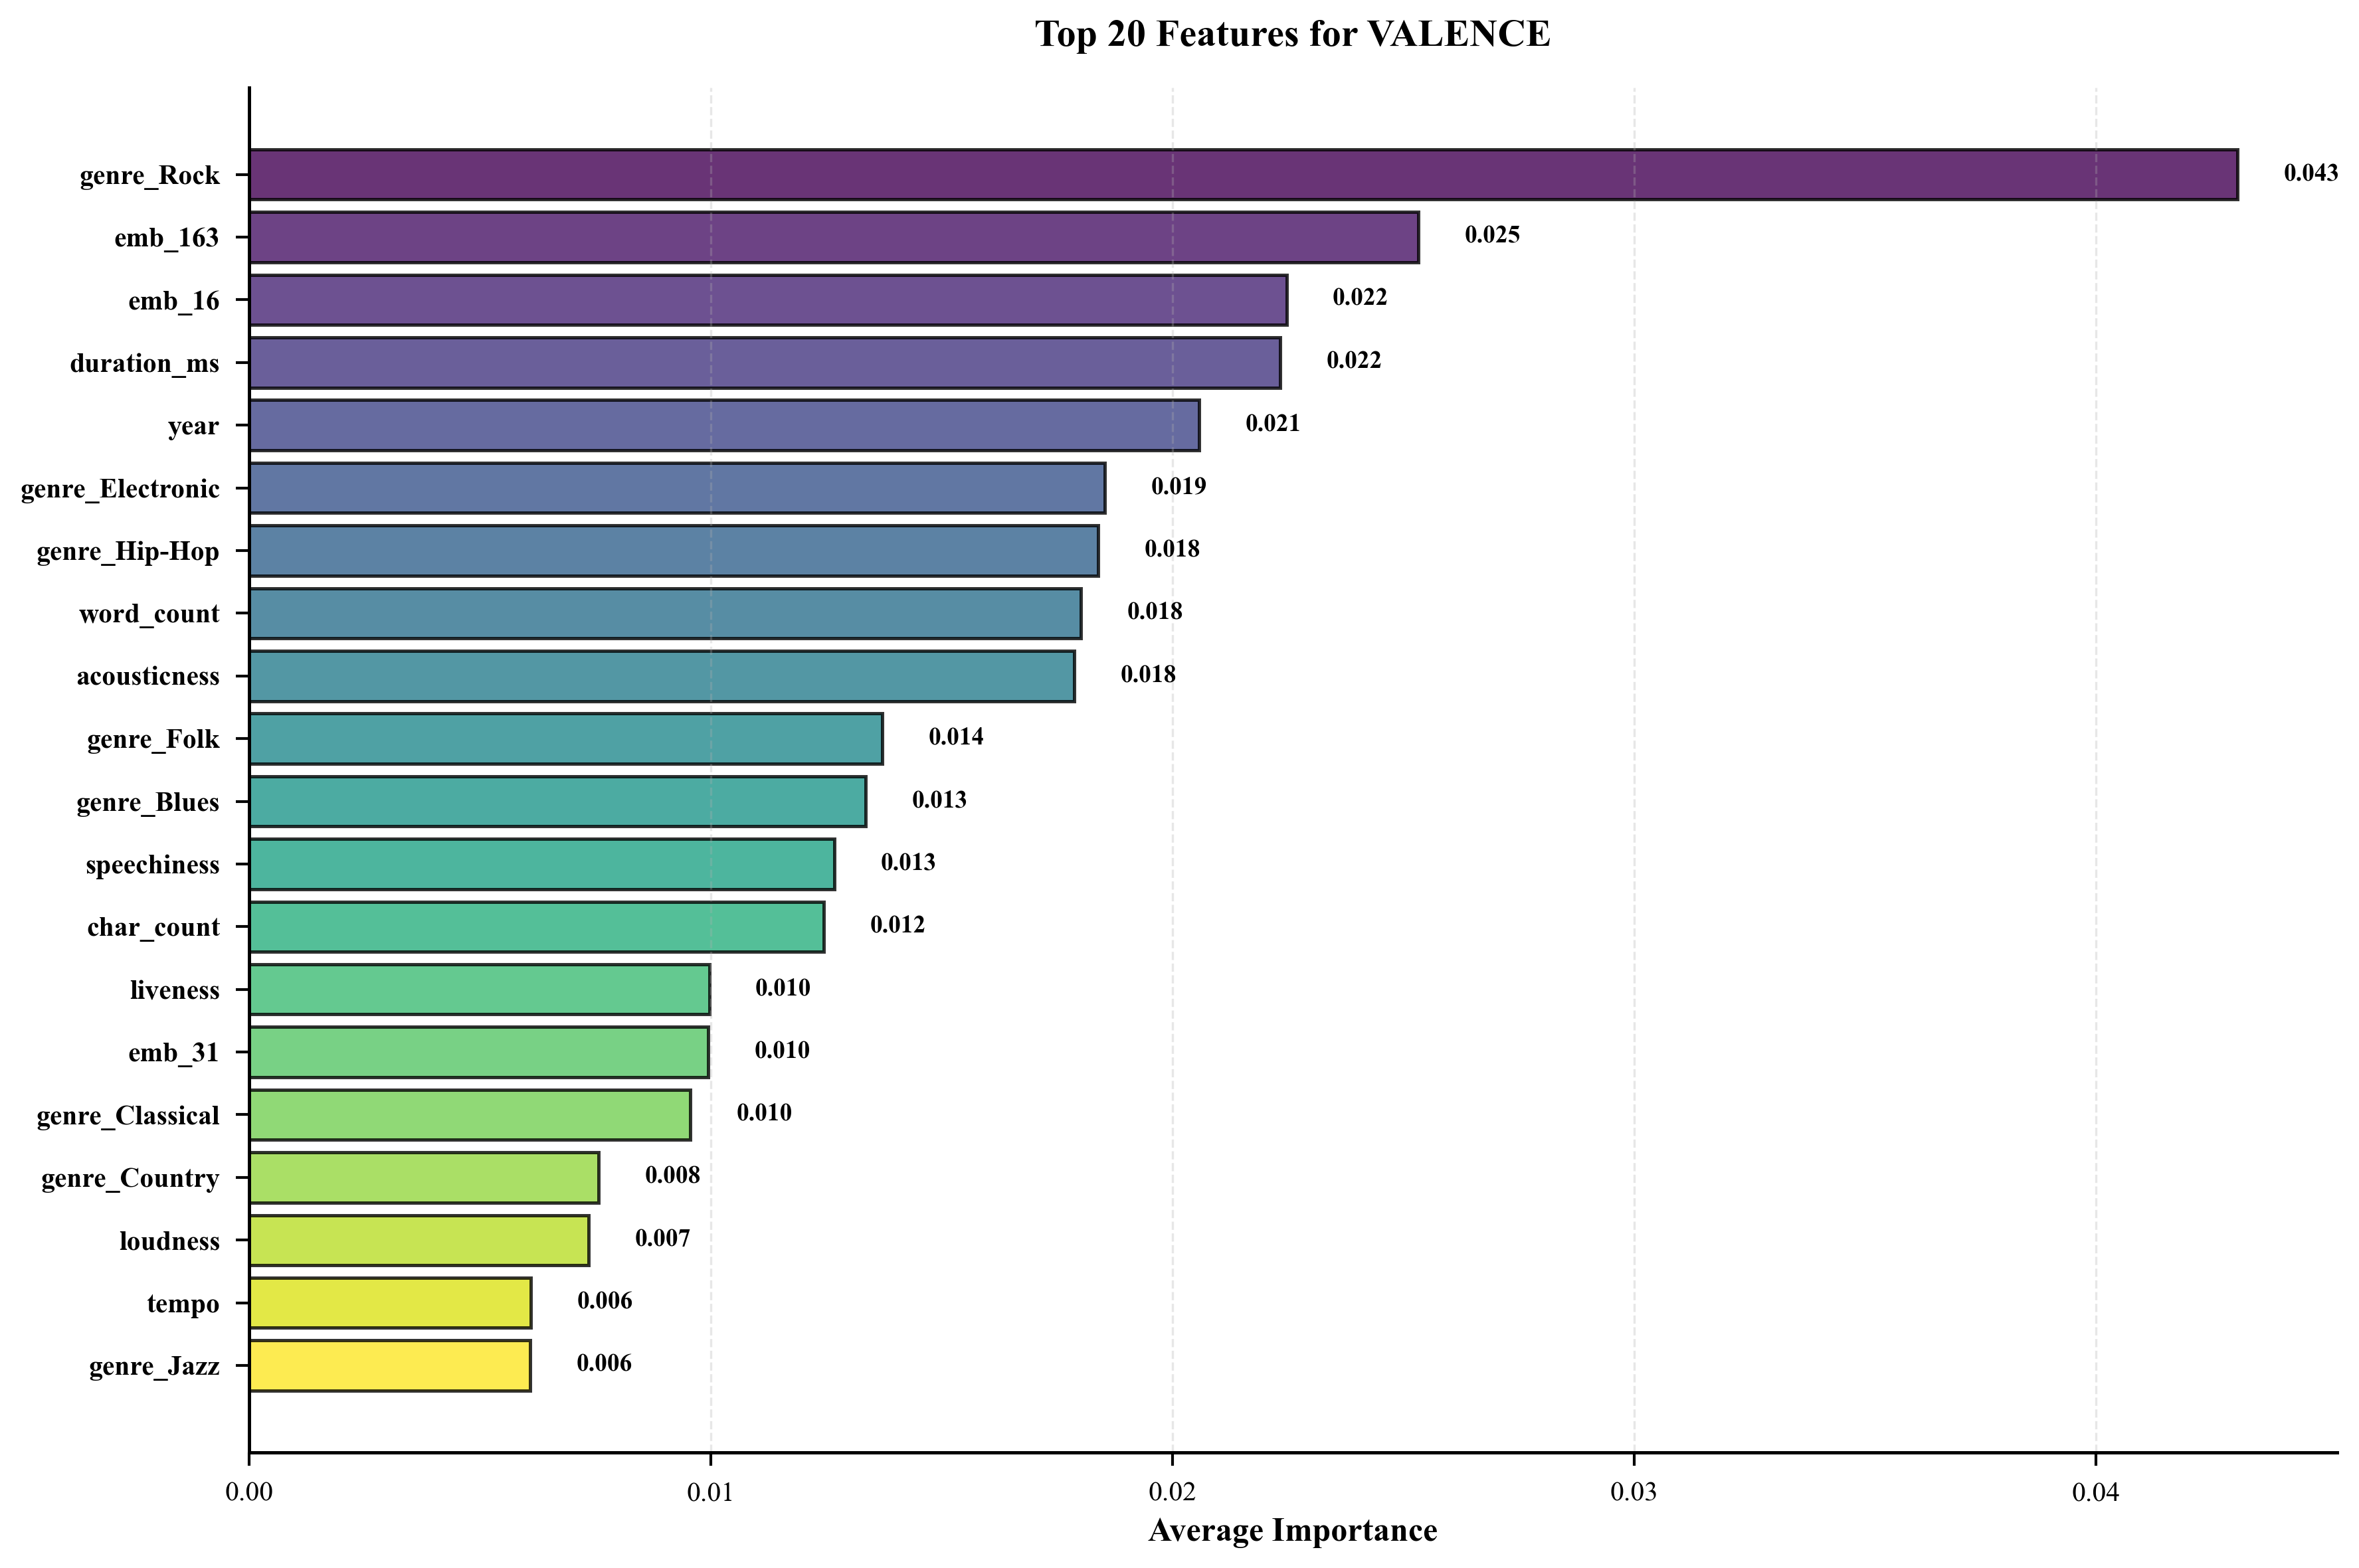

💾 Saved: feature_importance_valence.png


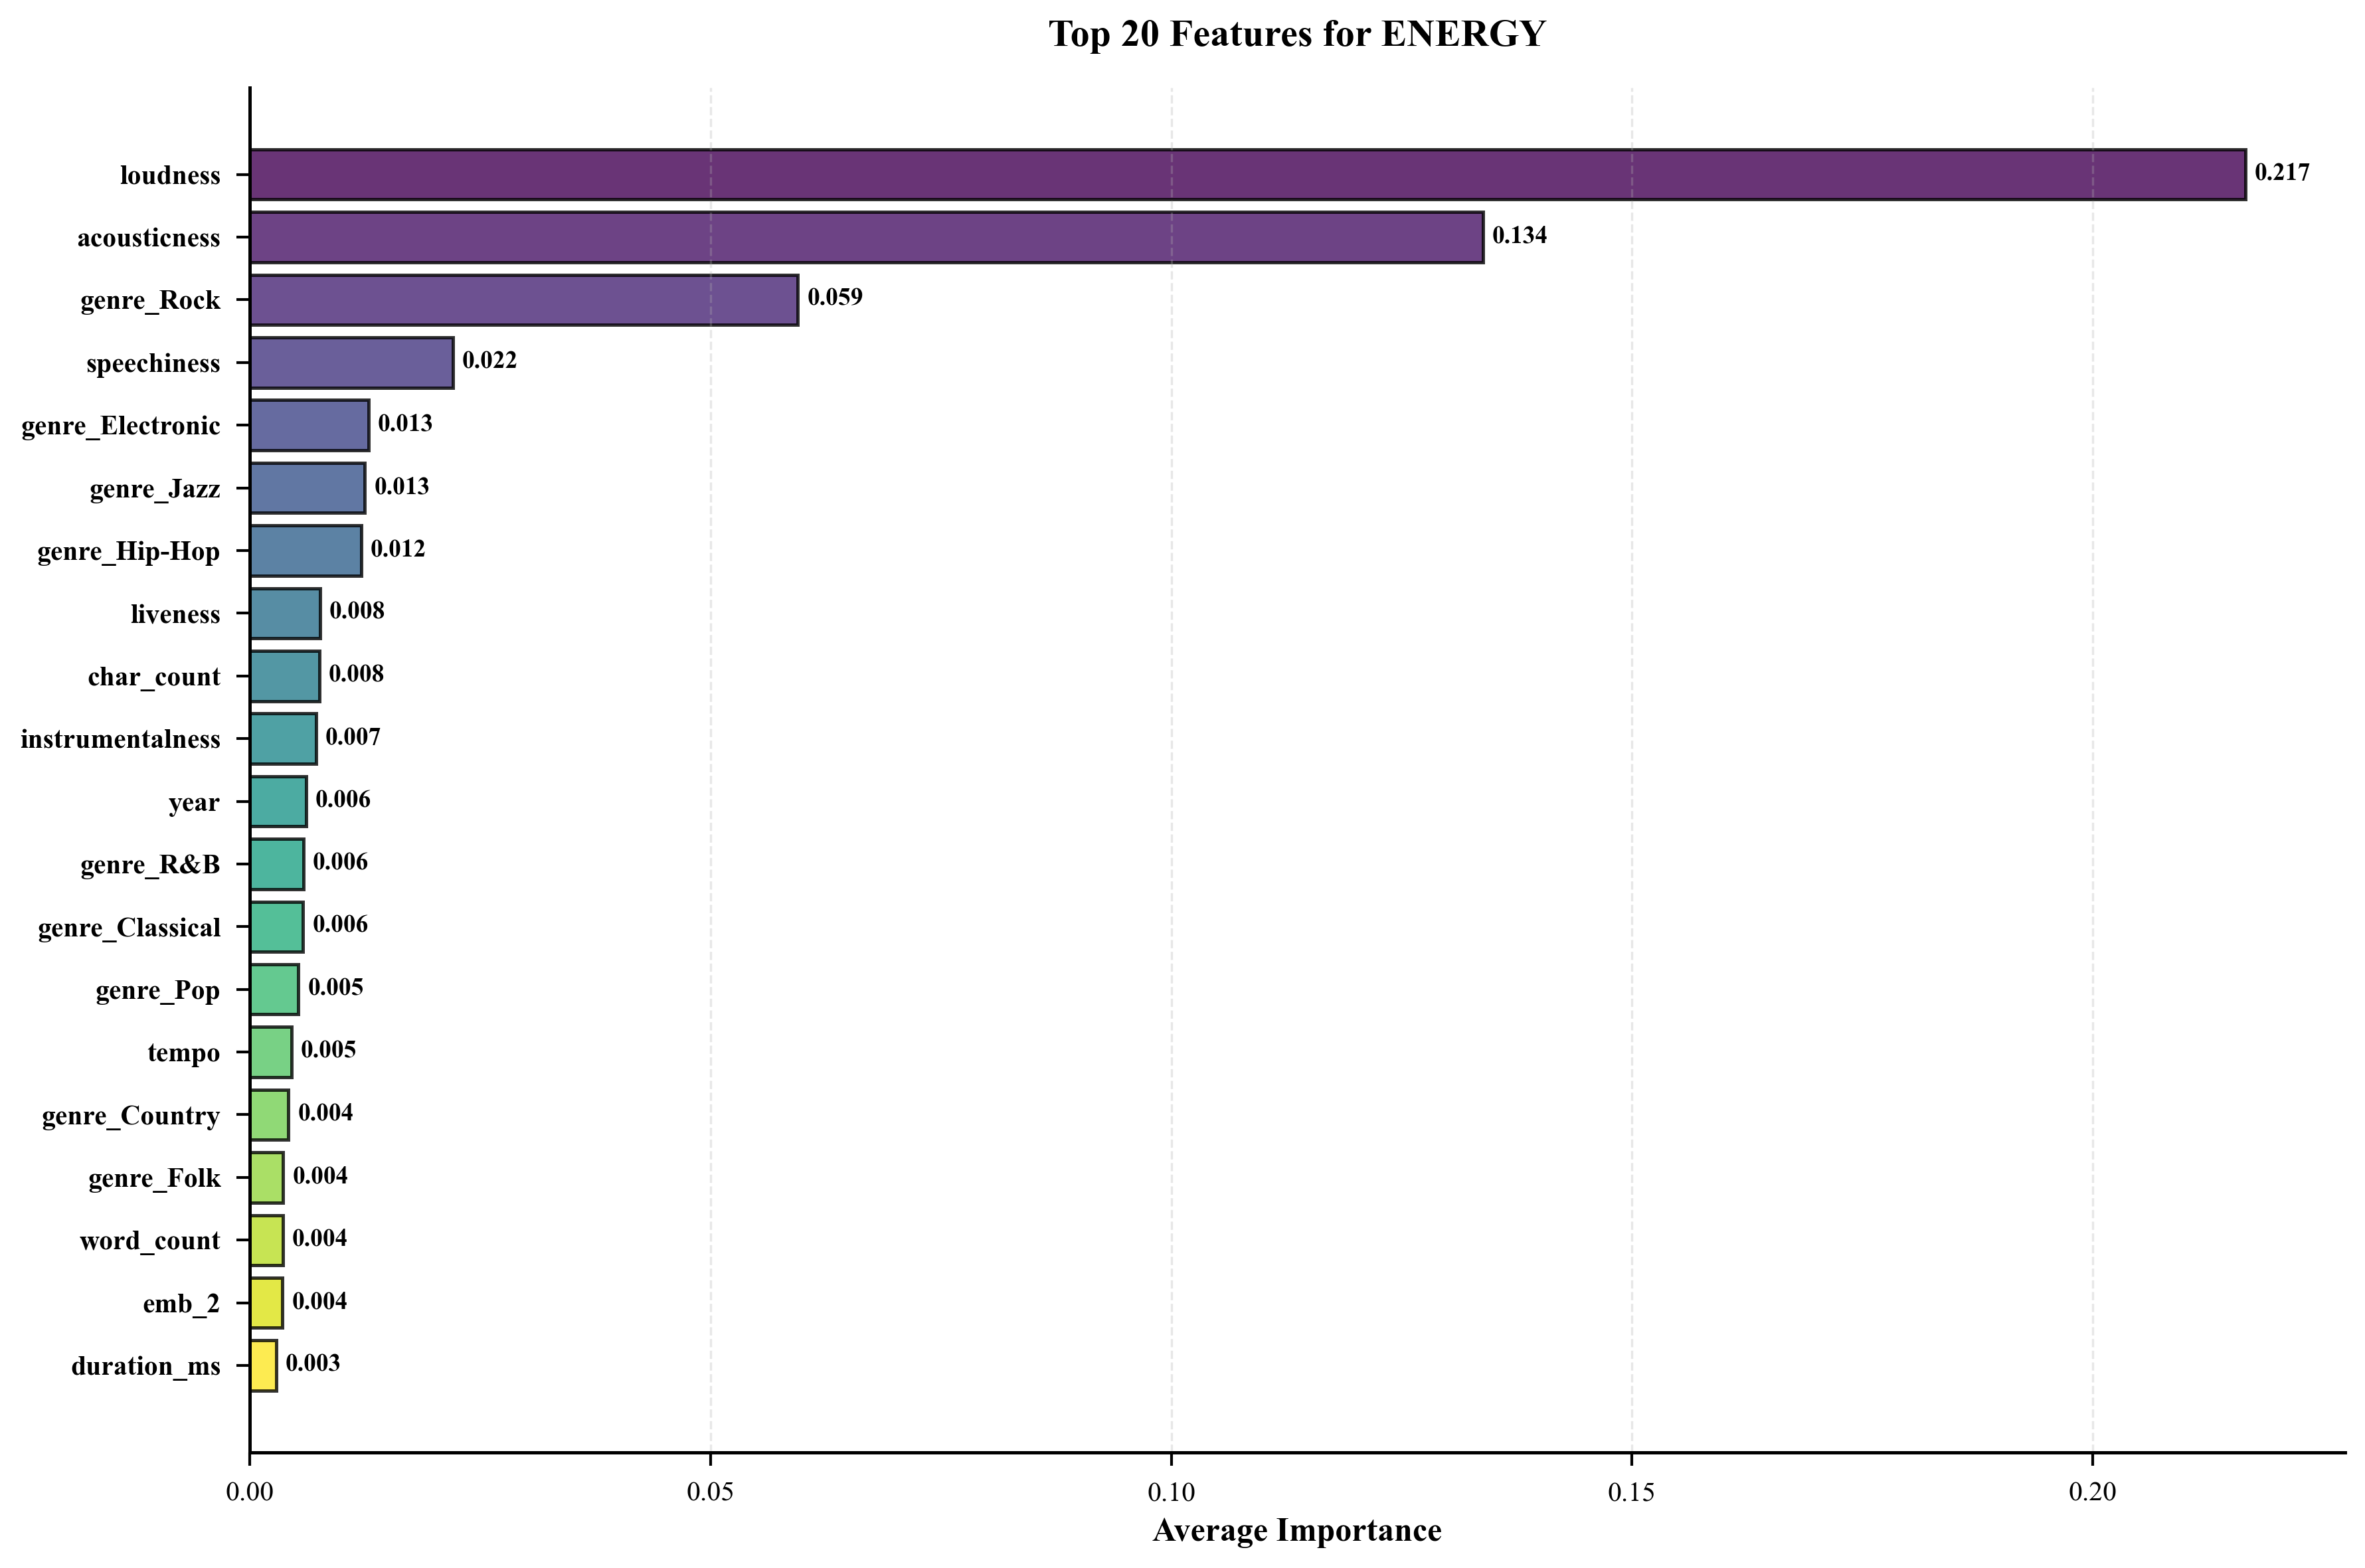

💾 Saved: feature_importance_energy.png


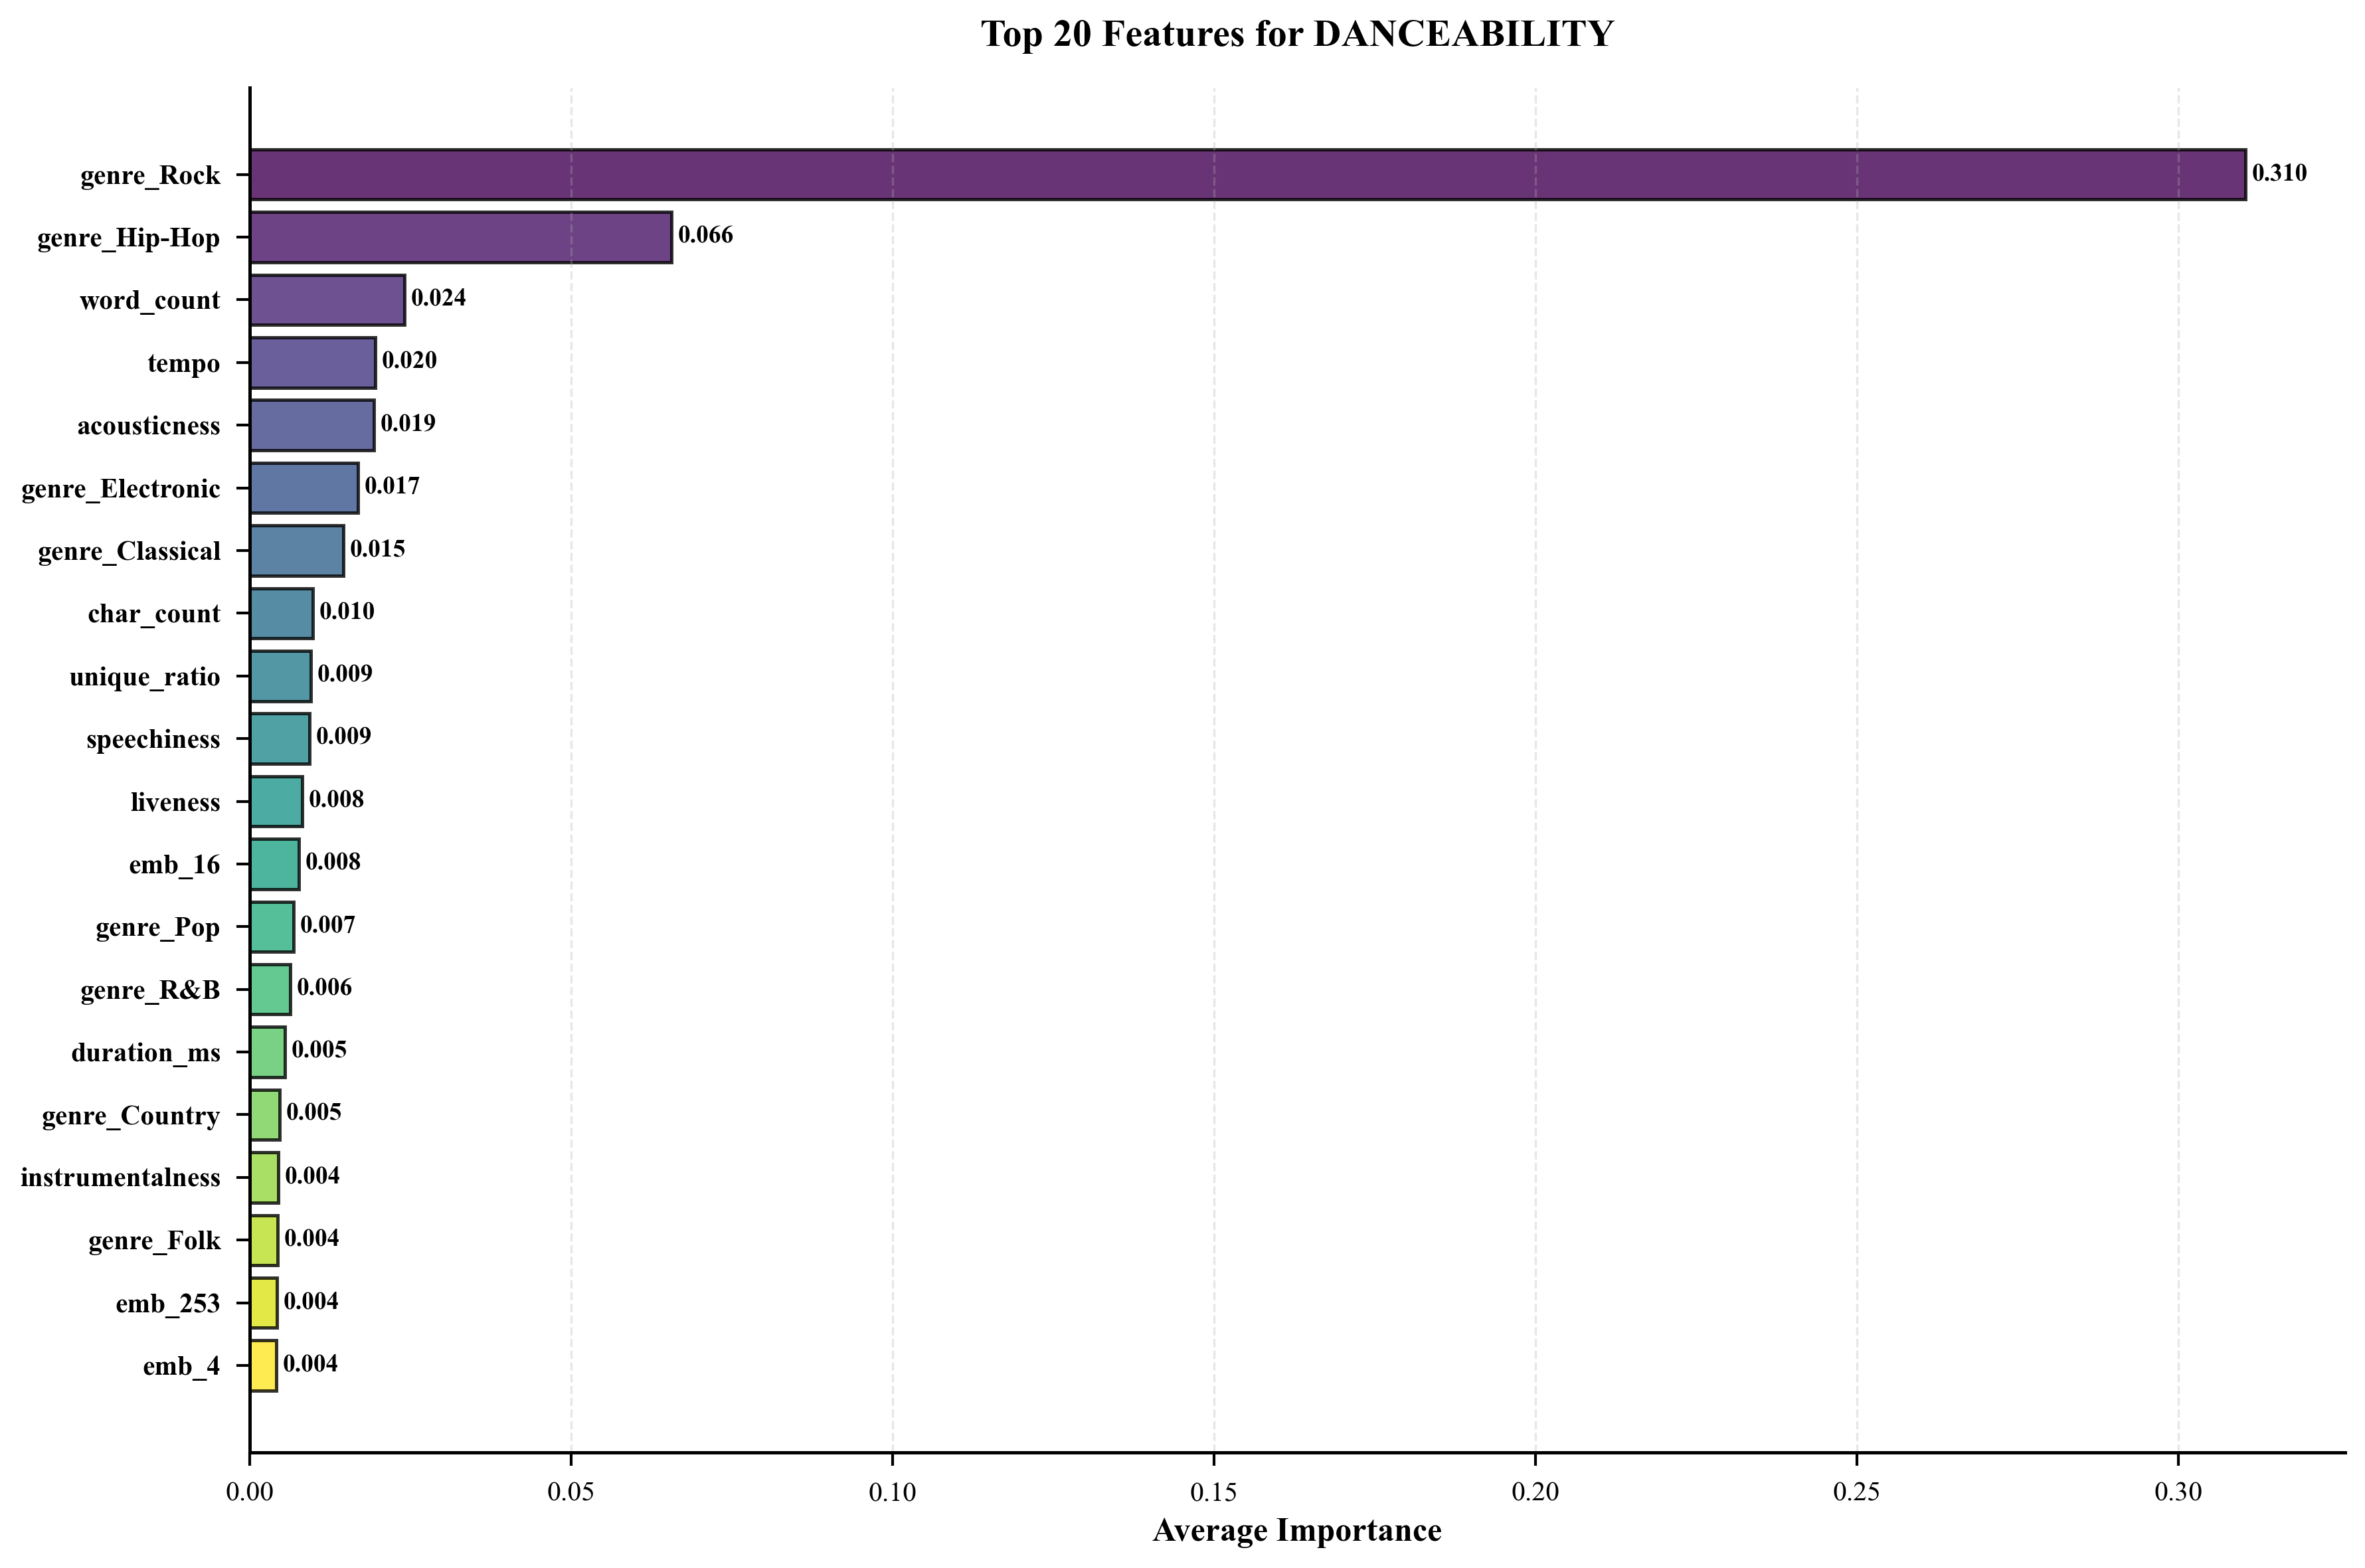

💾 Saved: feature_importance_danceability.png


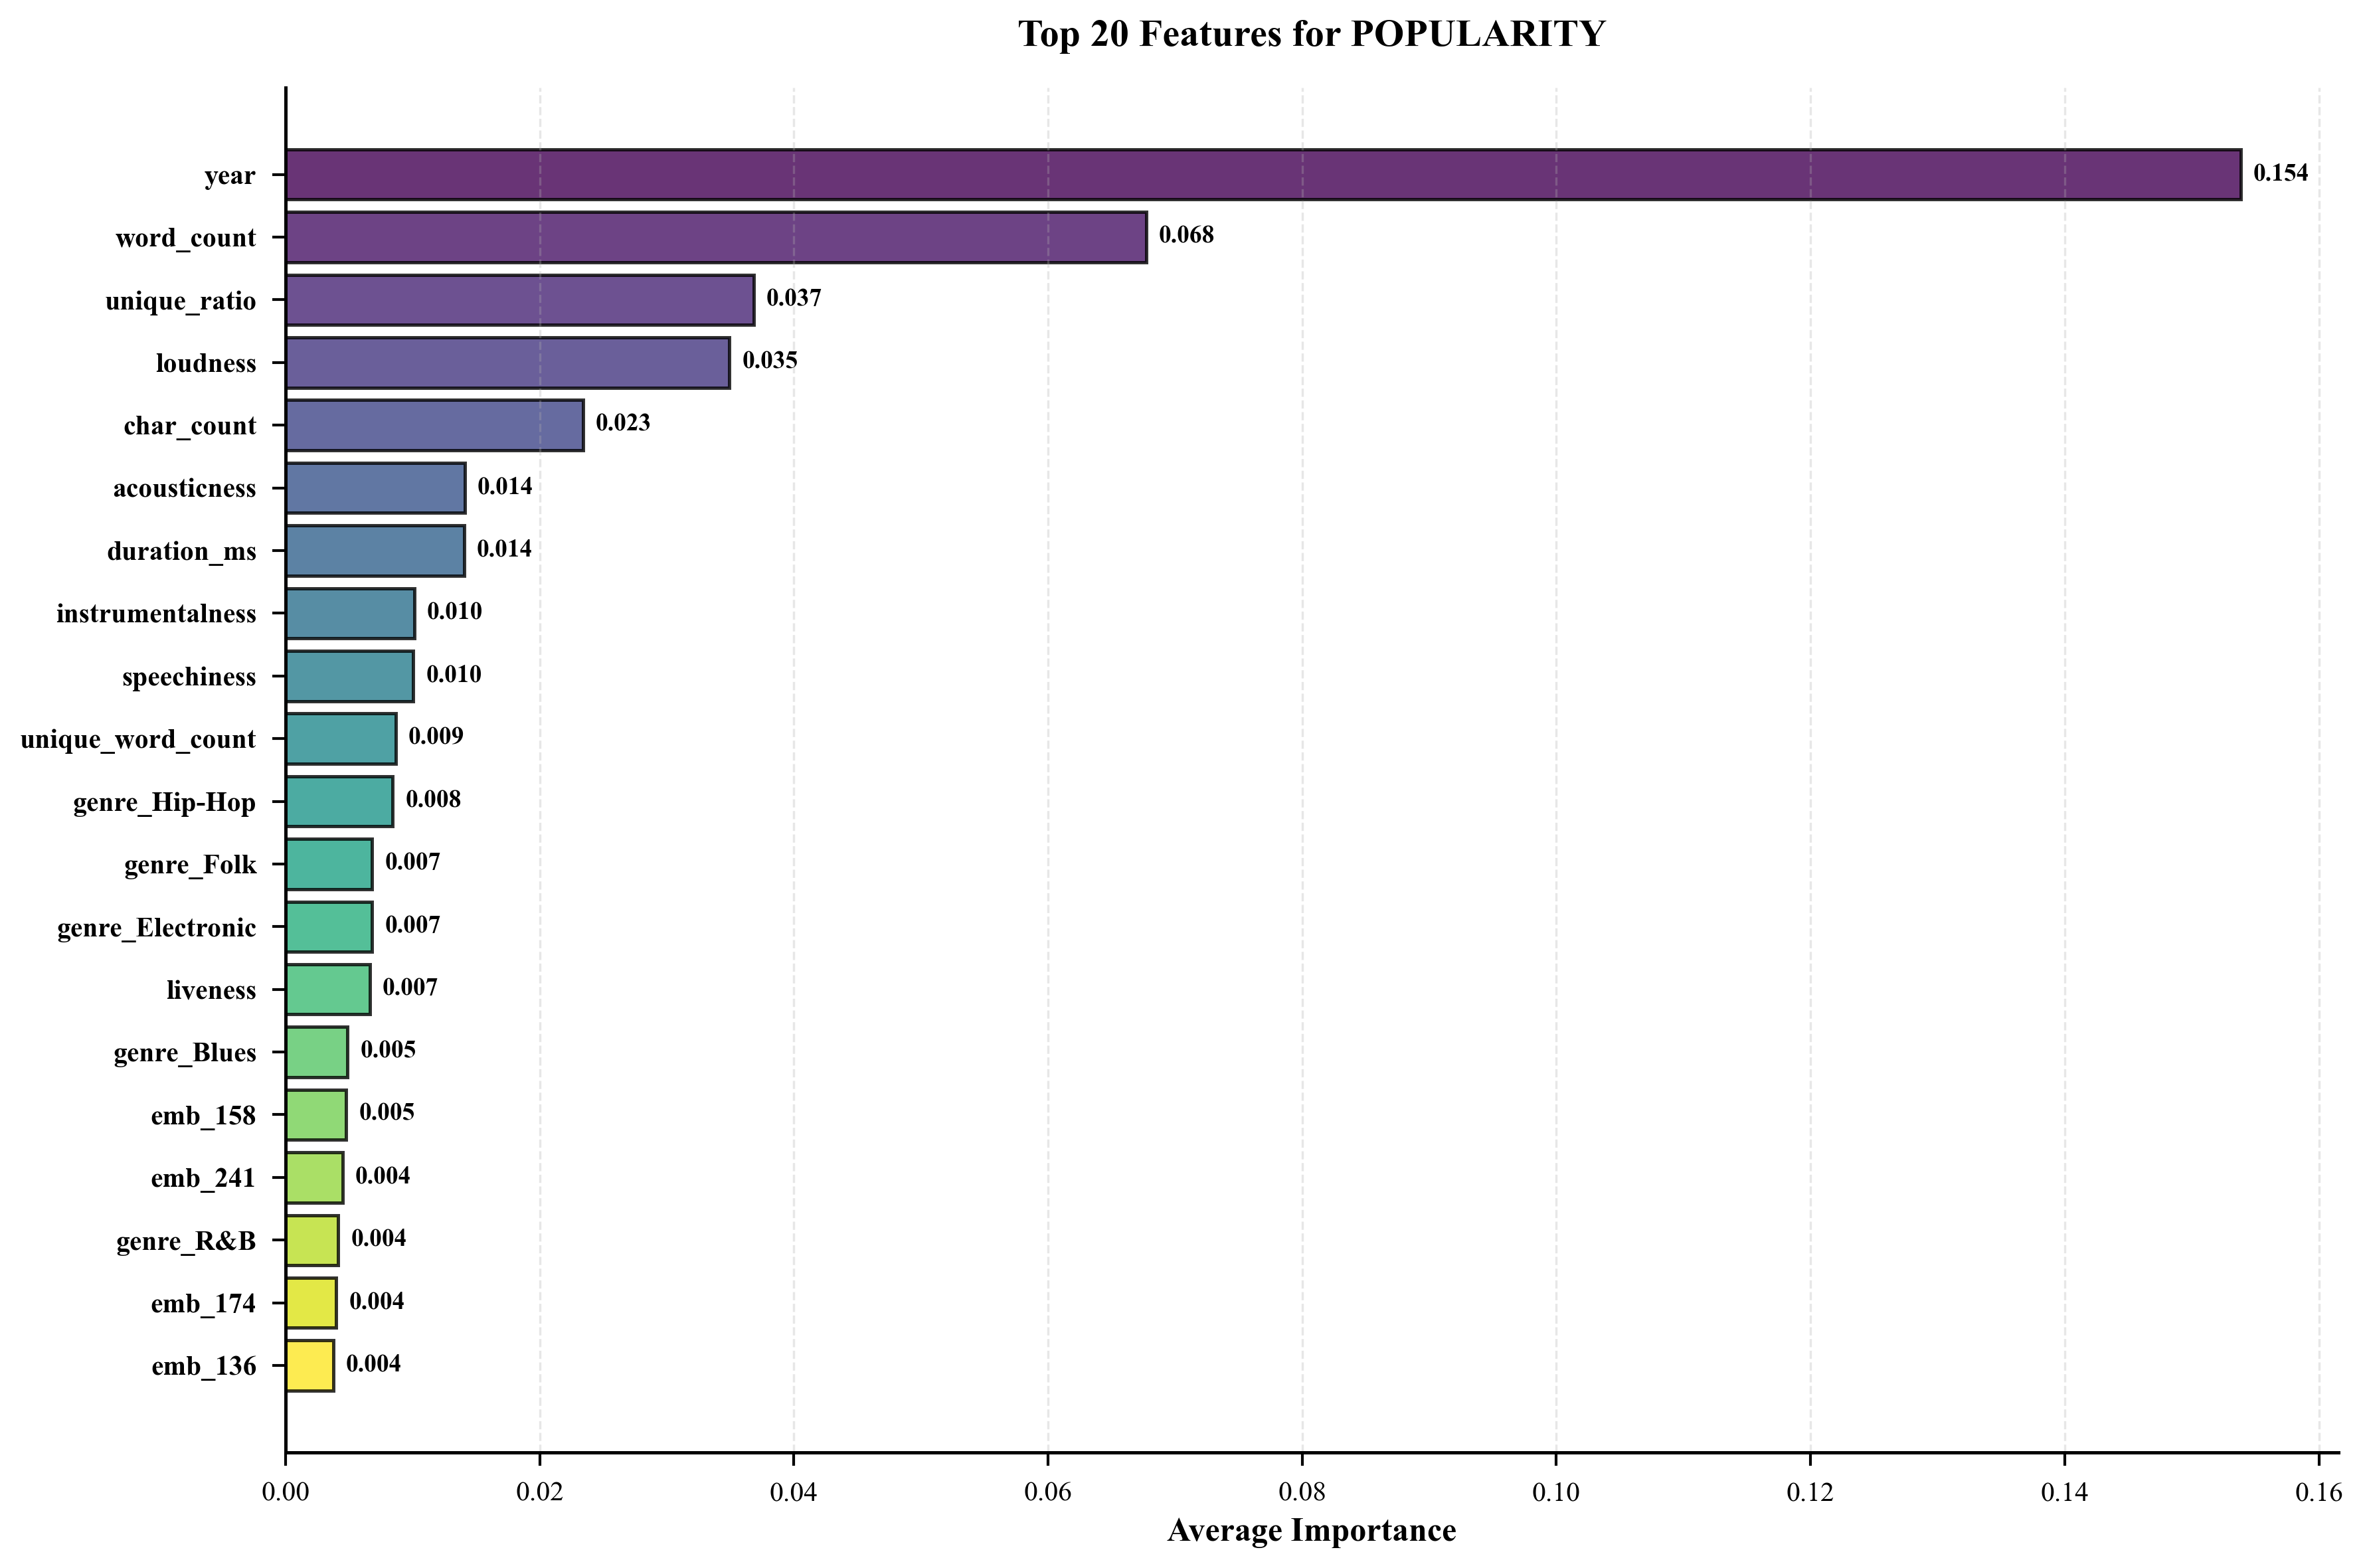

💾 Saved: feature_importance_popularity.png


In [25]:
def plot_top_features(all_importance, target, top_n=20):
    """Plot top N features for a target"""
    target_df = all_importance[all_importance['target'] == target].copy()
    agg_importance = target_df.groupby('feature')['importance'].mean().sort_values(ascending=False)
    top_features = agg_importance.head(top_n)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
    
    bars = ax.barh(range(len(top_features)), top_features.values, 
                   color=colors, edgecolor='black', alpha=0.8, linewidth=1.2)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features.index, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlabel('Average Importance', fontsize=12, fontweight='bold')
    ax.set_title(f'Top {top_n} Features for {target.upper()}', fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels
    for bar, val in zip(bars, top_features.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    return fig

# Generate plots
for target in TARGETS:
    fig = plot_top_features(all_importance_df, target, top_n=20)
    fig_path = FIGURES_DIR / f"feature_importance_{target}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved: {fig_path.name}")

---
## 🧠 Explainable AI (XAI): SHAP Global Analysis
SHAP (SHapley Additive exPlanations) provides a mathematically grounded way to explain model predictions. Unlike simple feature importance, SHAP shows the **direction** of the effect (e.g., does high energy increase or decrease valence?).

🧬 Running SHAP for valence (XGBoost_tuned)...


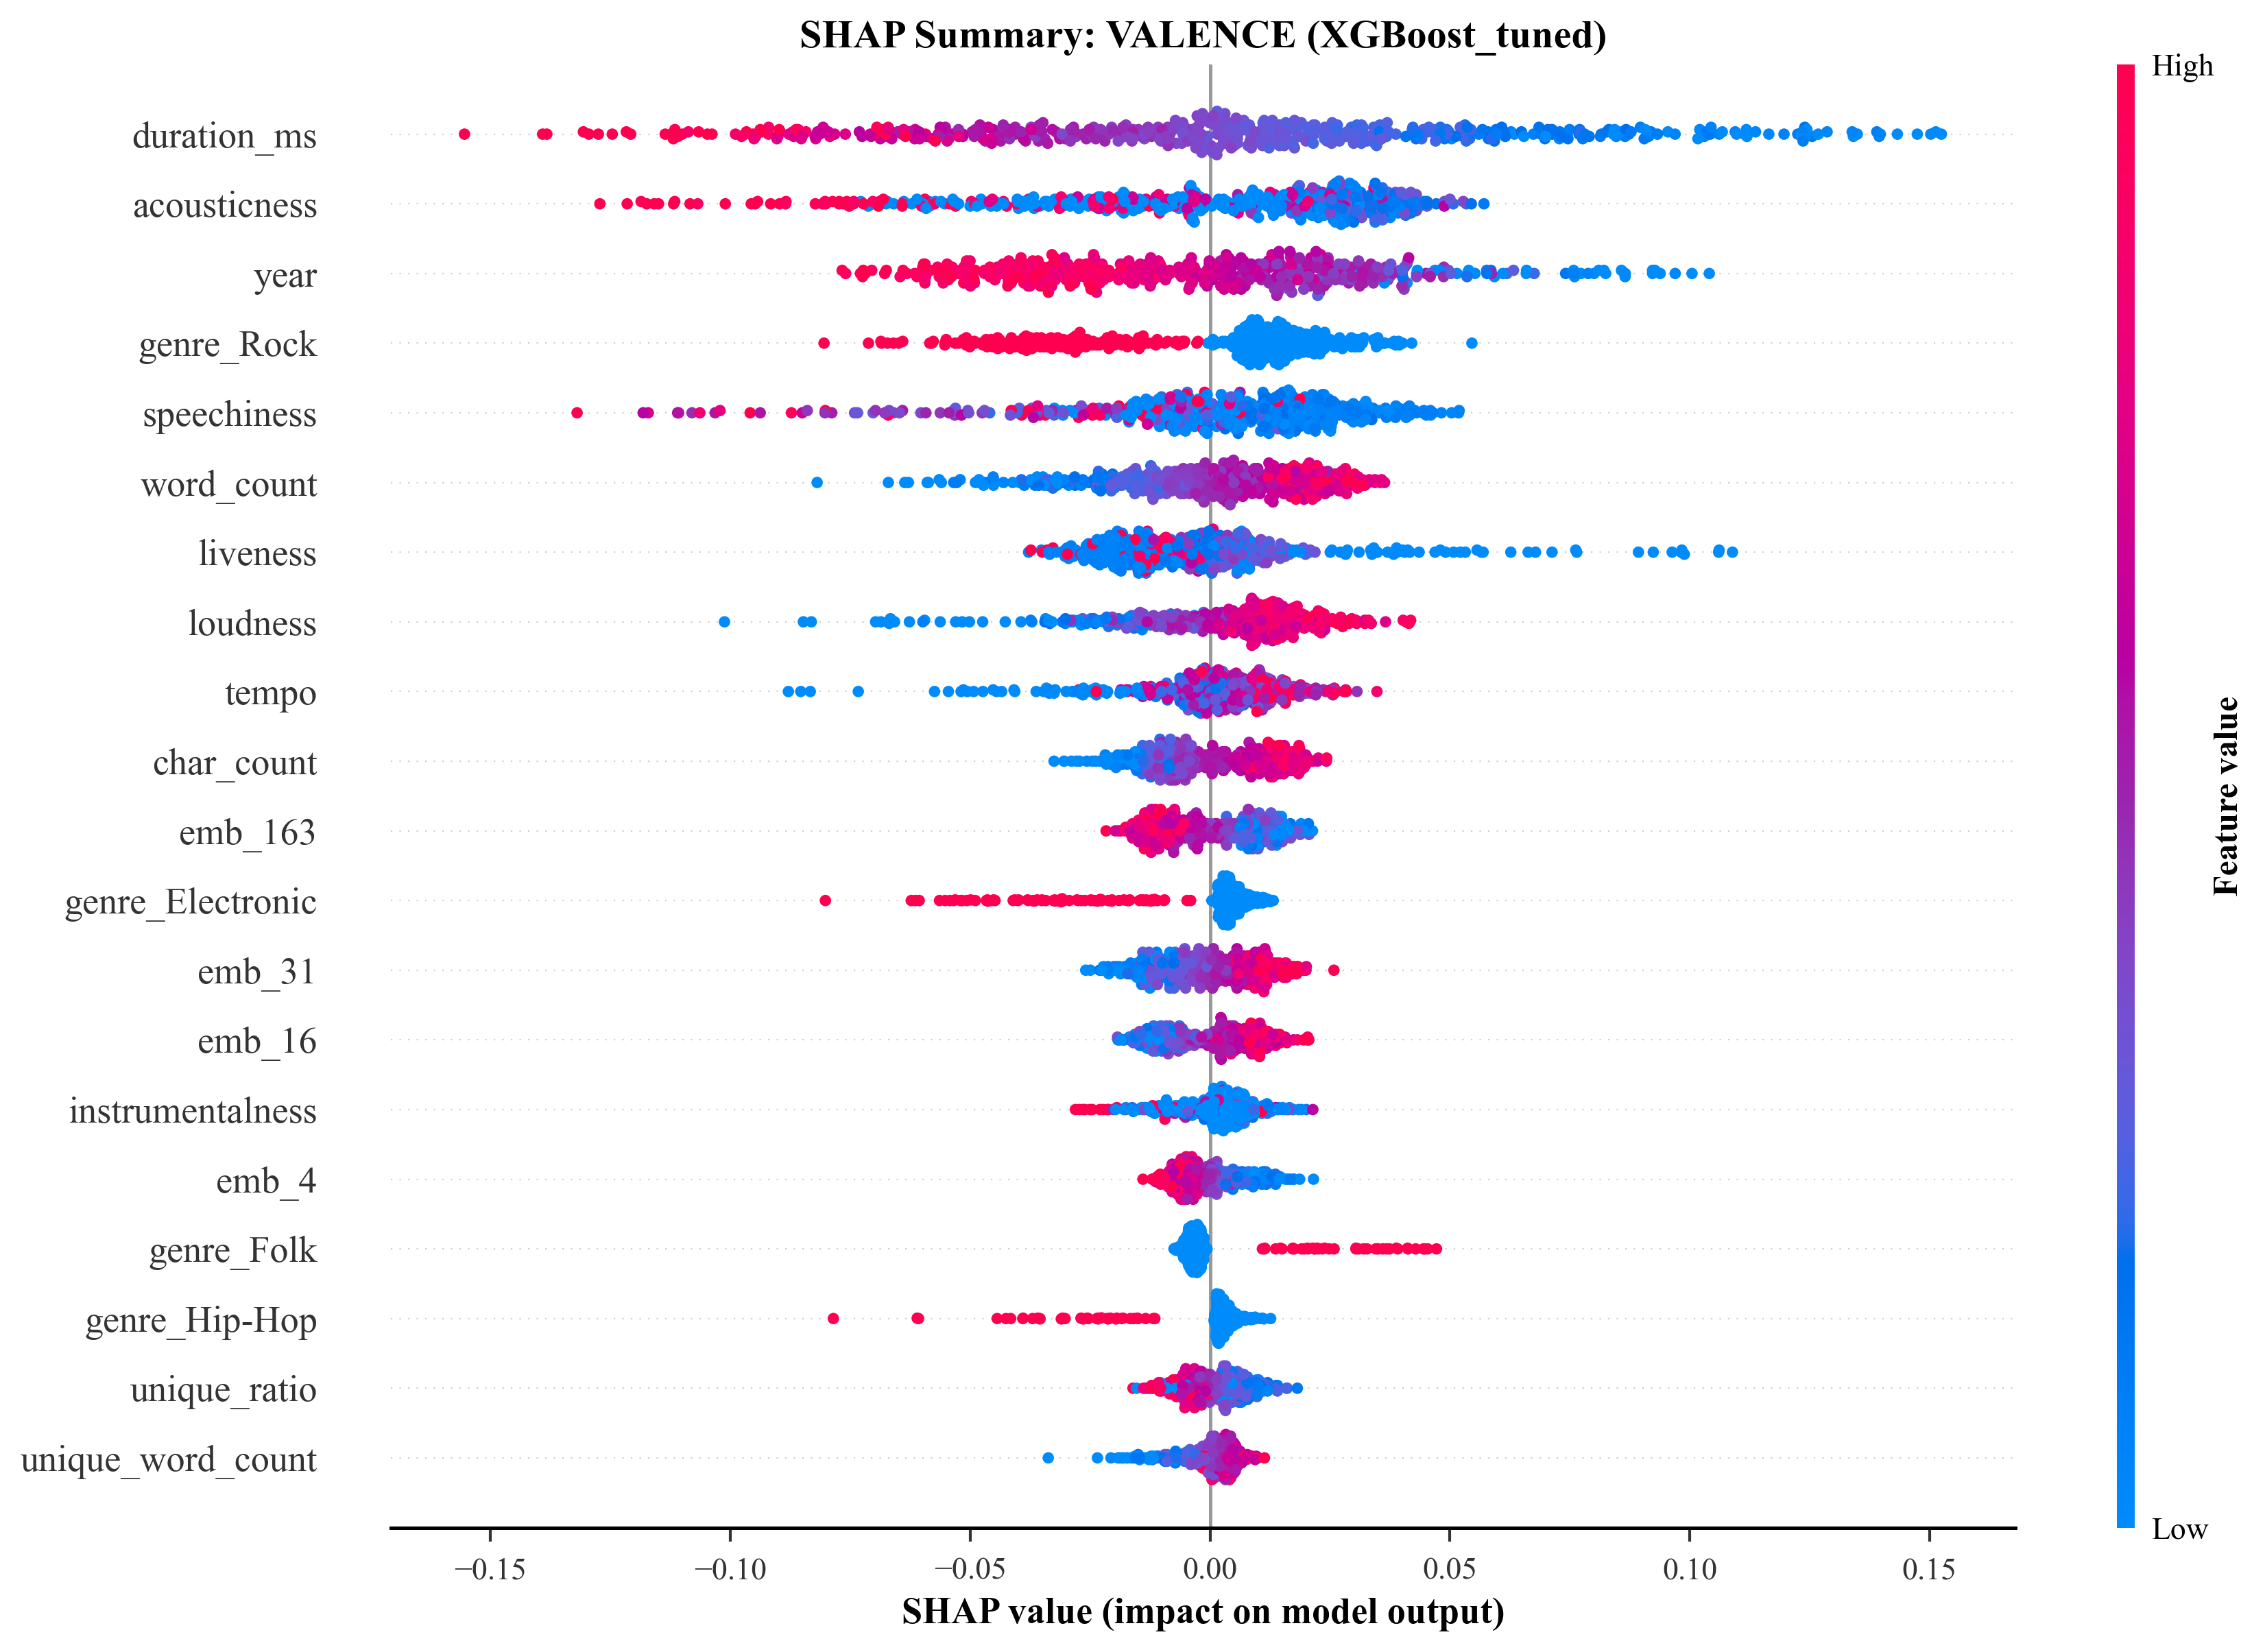

💾 Saved SHAP summary: shap_summary_valence.png
🧬 Running SHAP for energy (XGBoost_tuned)...


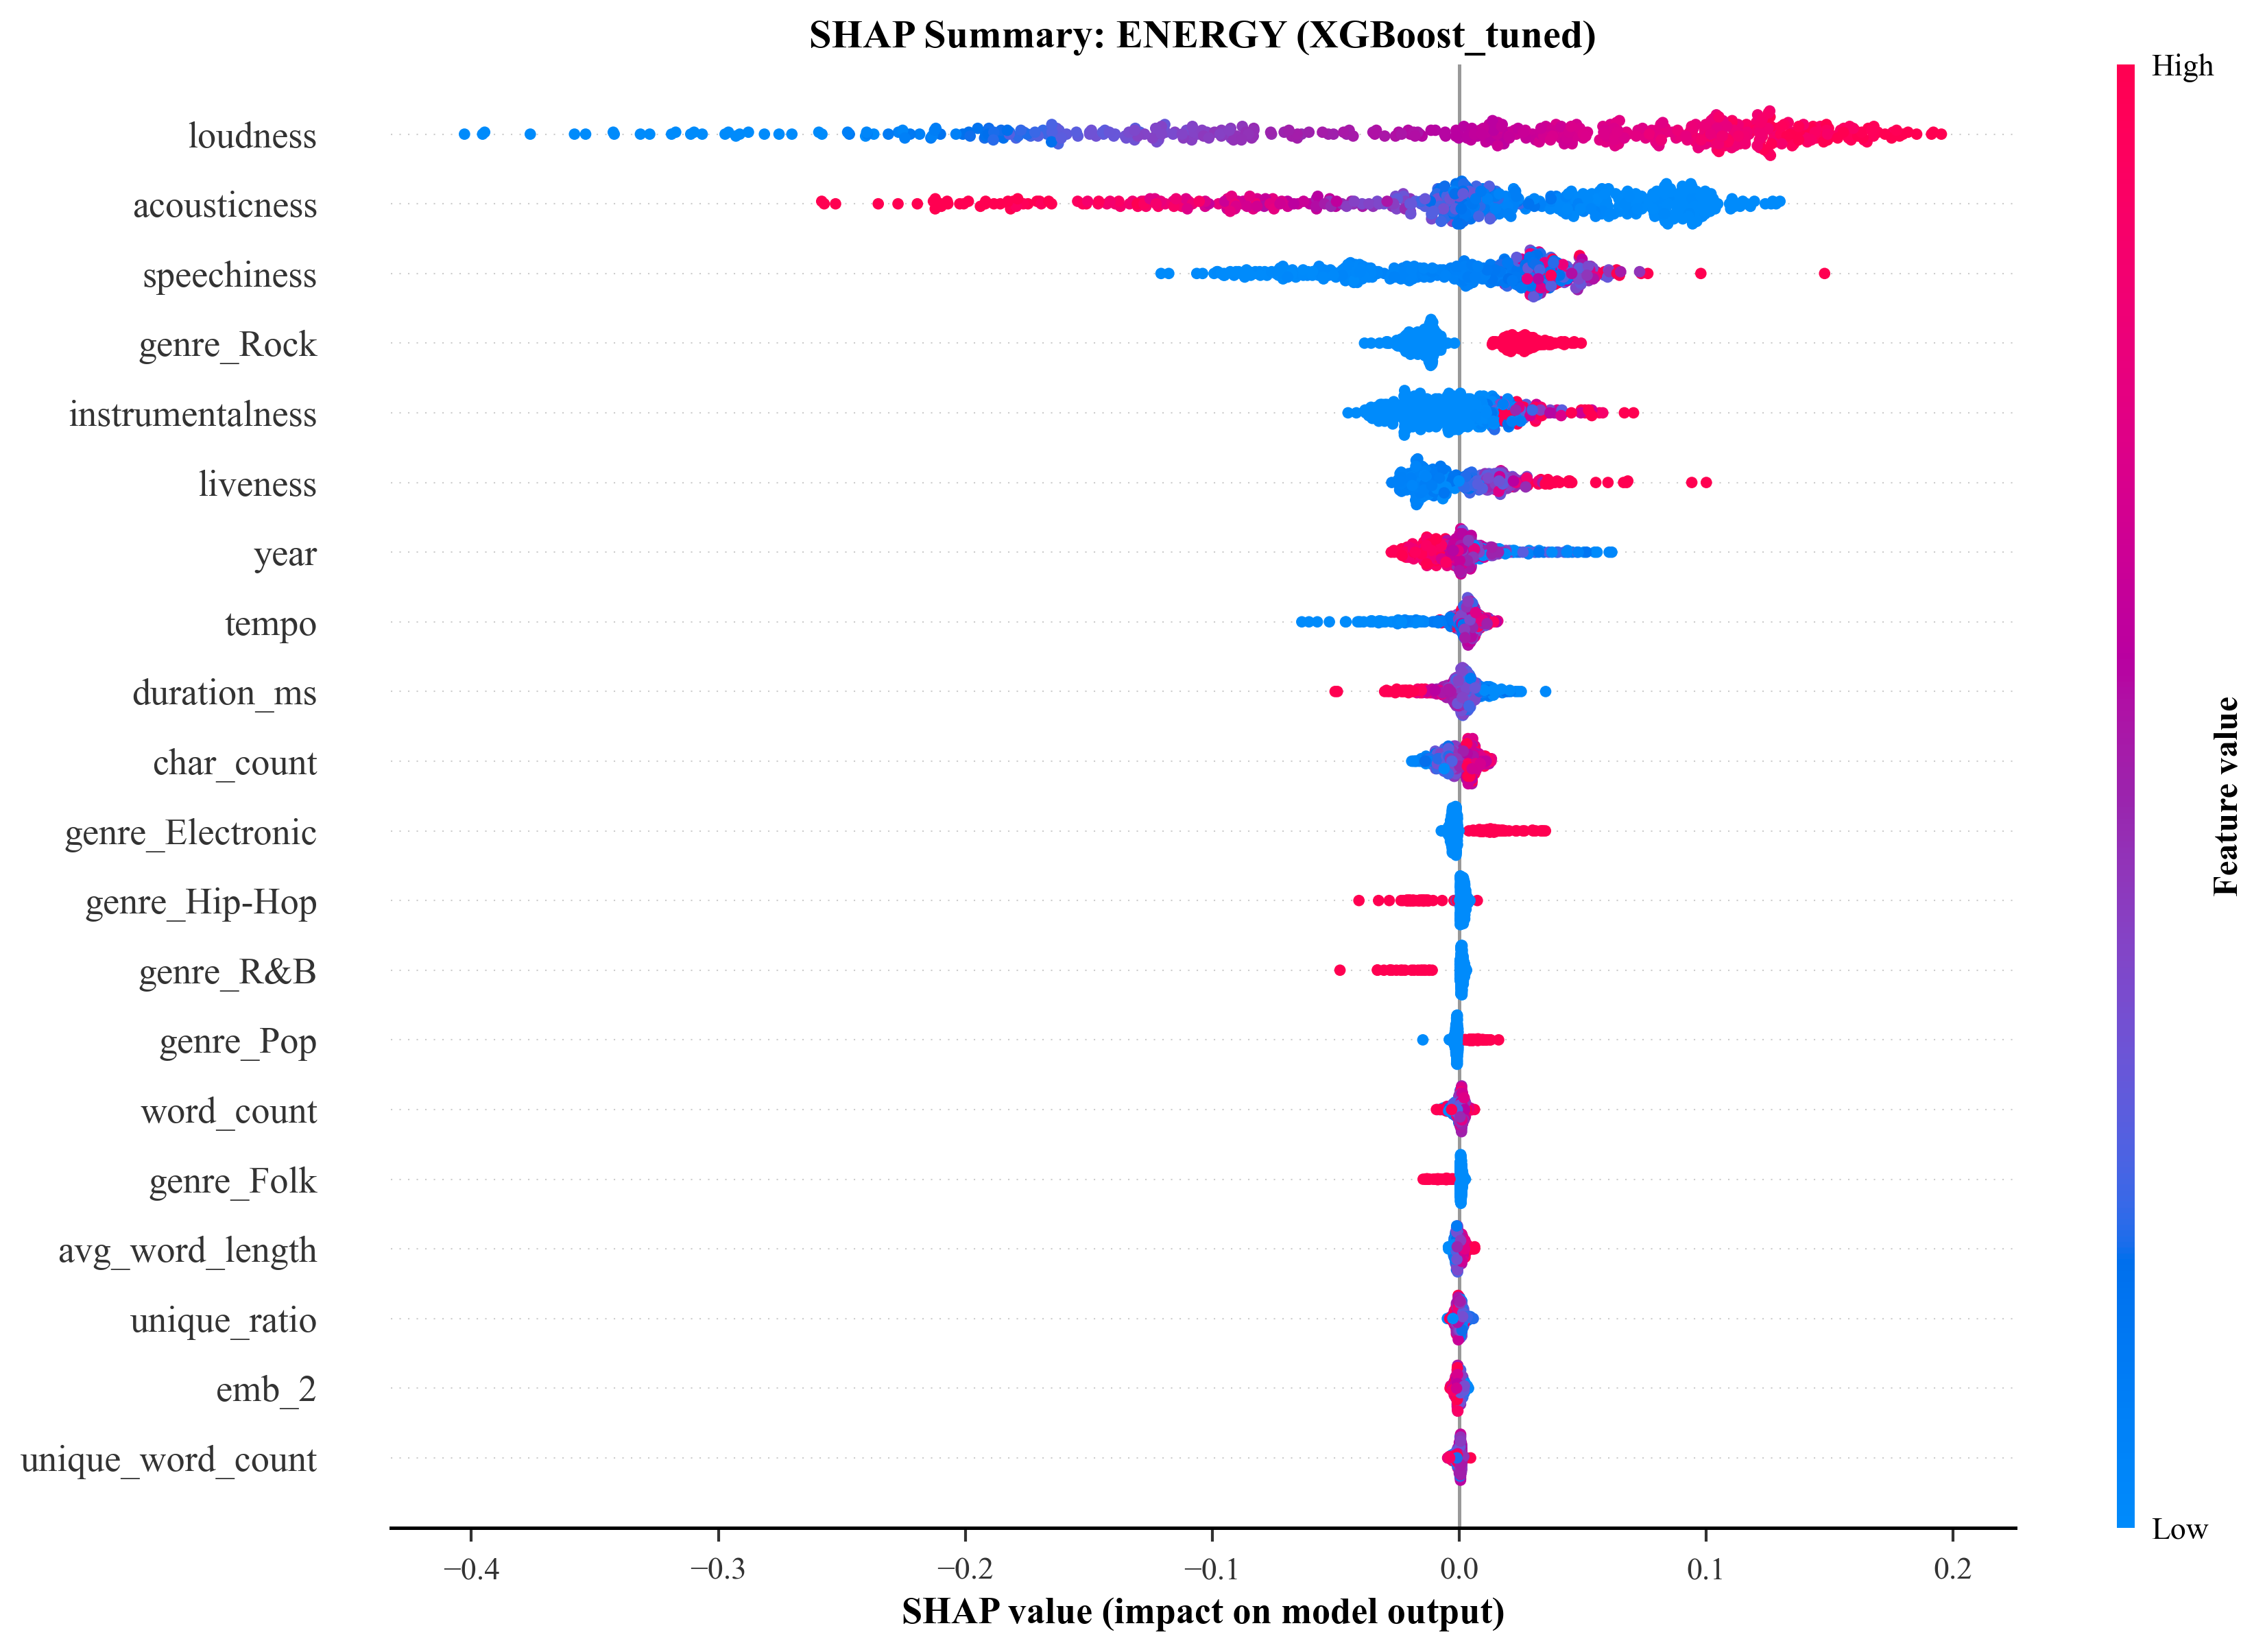

💾 Saved SHAP summary: shap_summary_energy.png
🧬 Running SHAP for danceability (XGBoost_tuned)...


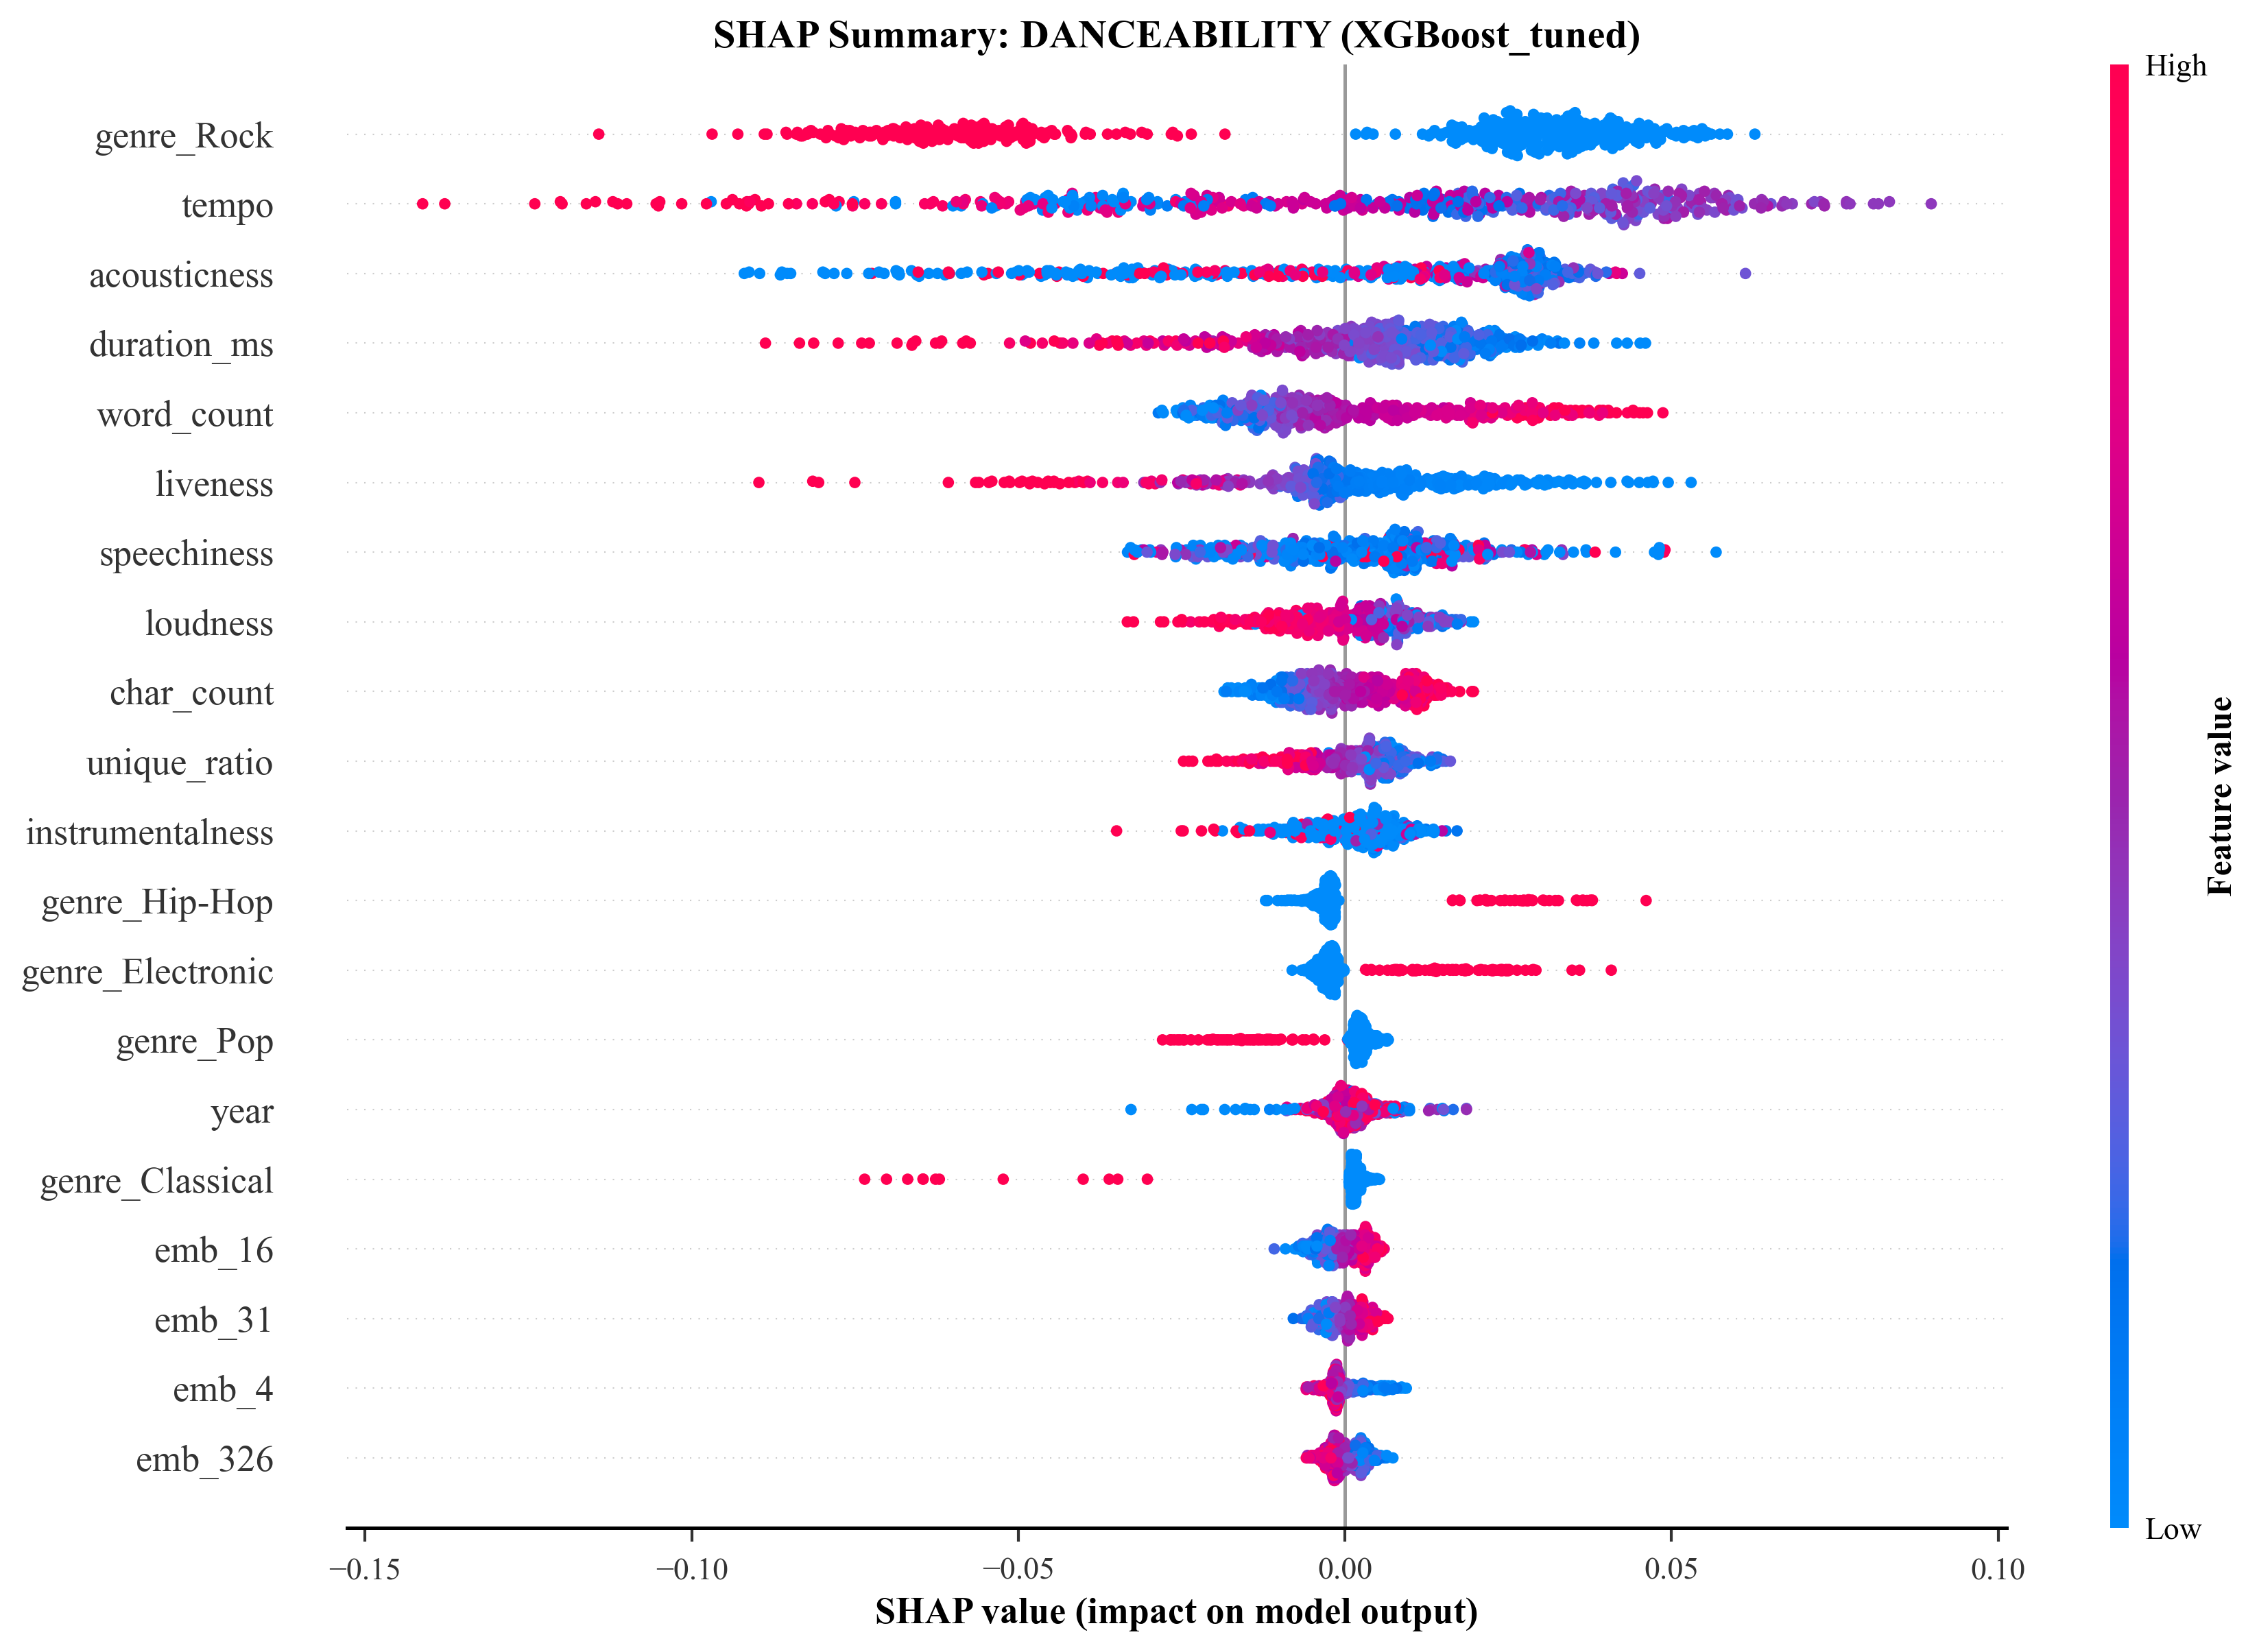

💾 Saved SHAP summary: shap_summary_danceability.png
🧬 Running SHAP for popularity (CatBoost_tuned)...


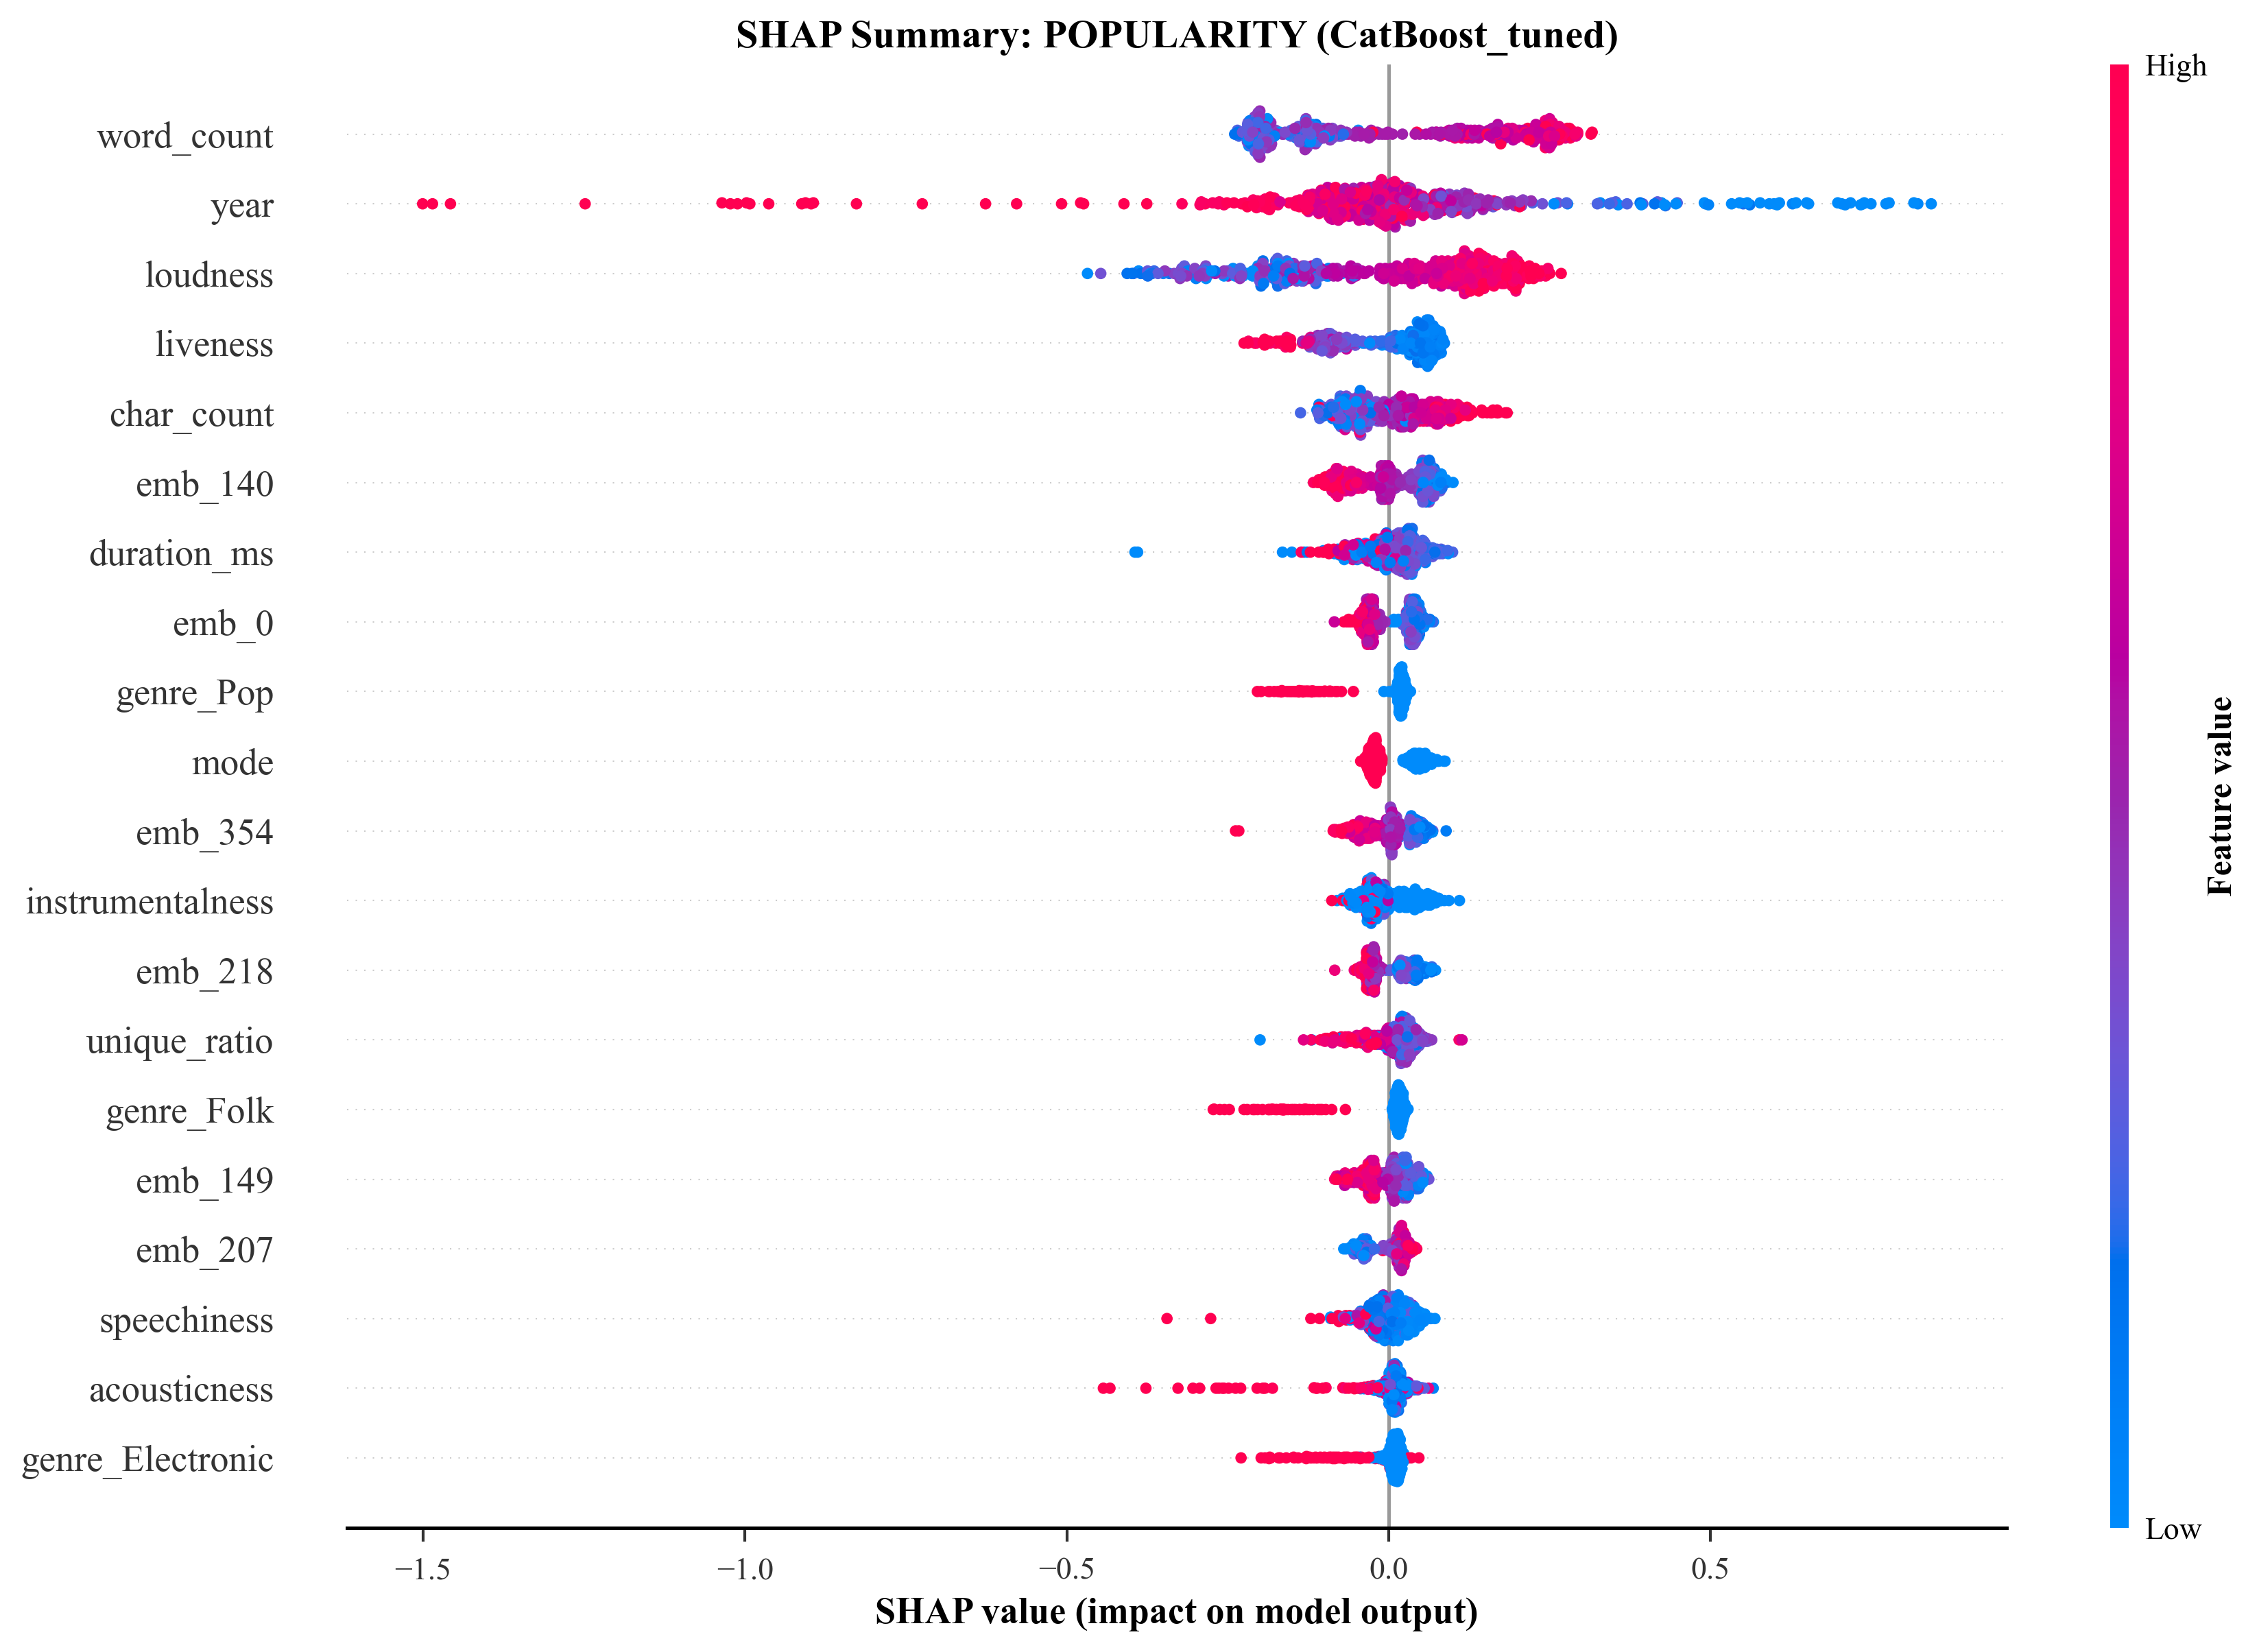

💾 Saved SHAP summary: shap_summary_popularity.png


In [26]:
def run_shap_analysis(target, model_name, X_sample):
    """Run SHAP analysis for a specific model and target"""
    model_path = MODELS_DIR / f"{model_name}_{target}.pkl"
    
    if not model_path.exists():
        print(f"⚠️ Model not found: {model_path}")
        return
    
    print(f"🧬 Running SHAP for {target} ({model_name})...")
    model = joblib.load(model_path)
    
    # Create explainer
    # For XGBoost and CatBoost, we can use TreeExplainer which is very fast
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    
    # Plot Summary
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, show=False, plot_size=(12, 8))
    plt.title(f"SHAP Summary: {target.upper()} ({model_name})", fontsize=14, fontweight='bold')
    
    fig_path = FIGURES_DIR / f"shap_summary_{target}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved SHAP summary: {fig_path.name}")
    
    return shap_values

# Use a sample of 500 instances for SHAP to keep it fast
SHAP_SAMPLE_SIZE = 500
X_shap_sample = X_val.sample(min(SHAP_SAMPLE_SIZE, len(X_val)), random_state=42)

shap_results = {}
for target, model_name in TOP_MODELS.items():
    shap_val = run_shap_analysis(target, model_name, X_shap_sample)
    shap_results[target] = shap_val

---
## 📊 SHAP Visualization 2: Bar Plot (Mean Absolute Values)
Cleaner than summary plots for academic papers - shows average impact magnitude without direction.

---
## 🔍 Explainable AI (XAI): LIME Local Analysis
LIME (Local Interpretable Model-agnostic Explanations) helps us understand **why** the model made a specific prediction for a single song. It creates a local linear model around that specific instance.

🧐 Explaining prediction for first instance in validation set...

🔍 LIME for valence...


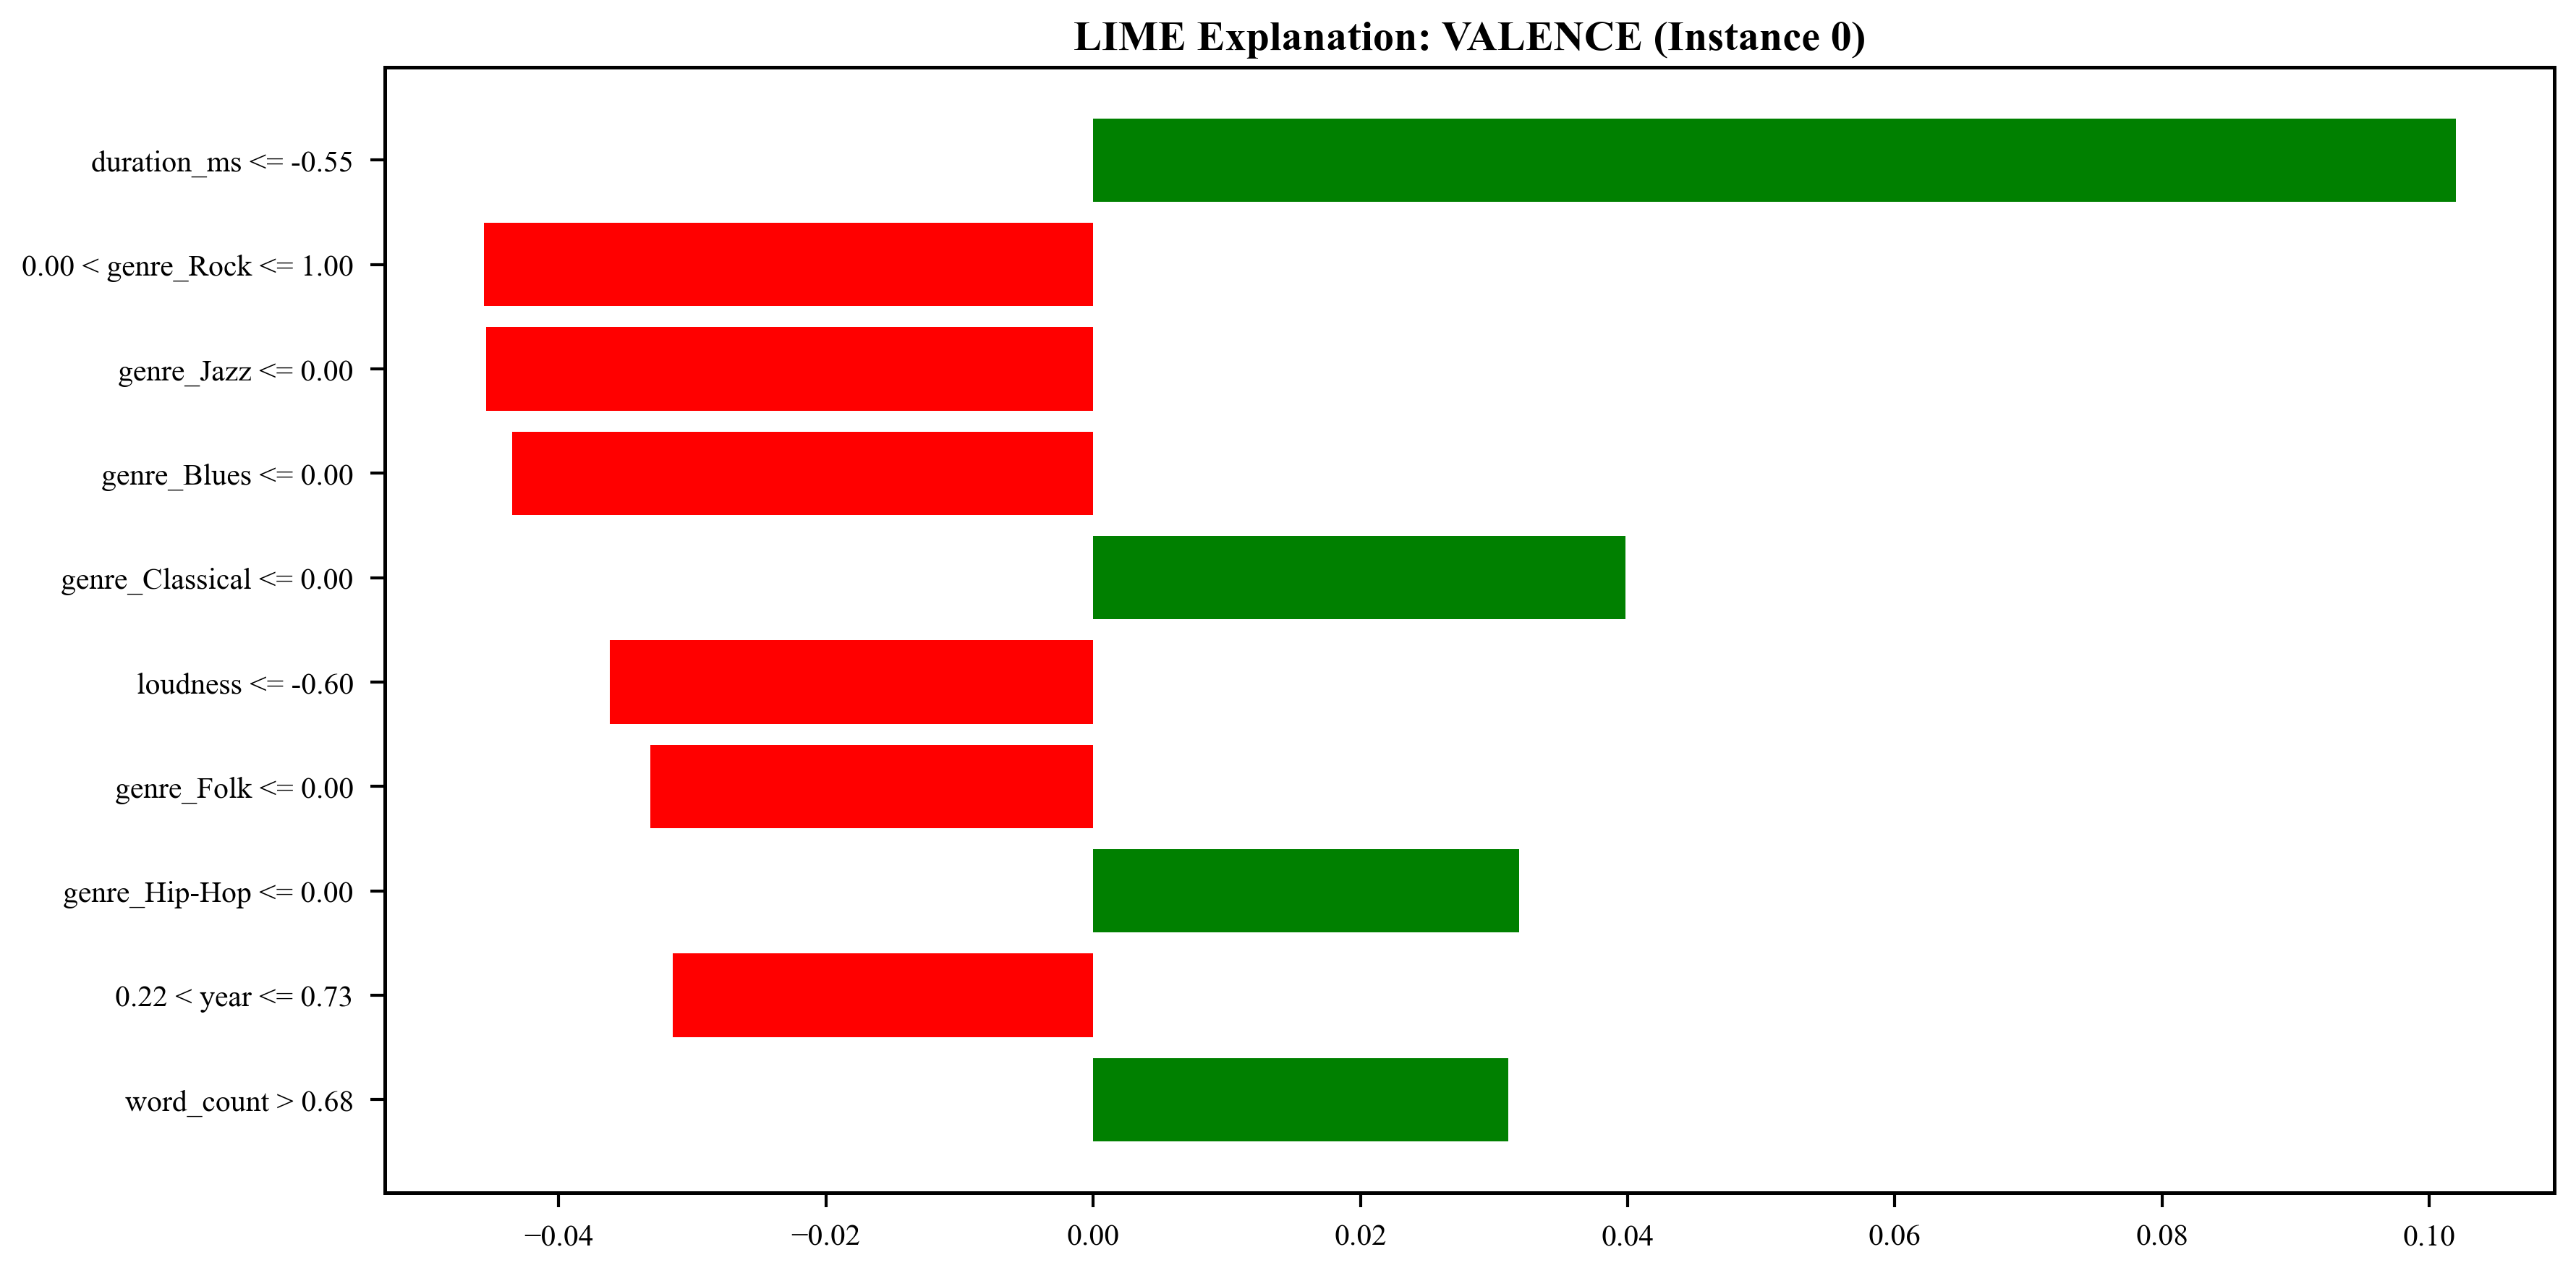


🔍 LIME for energy...


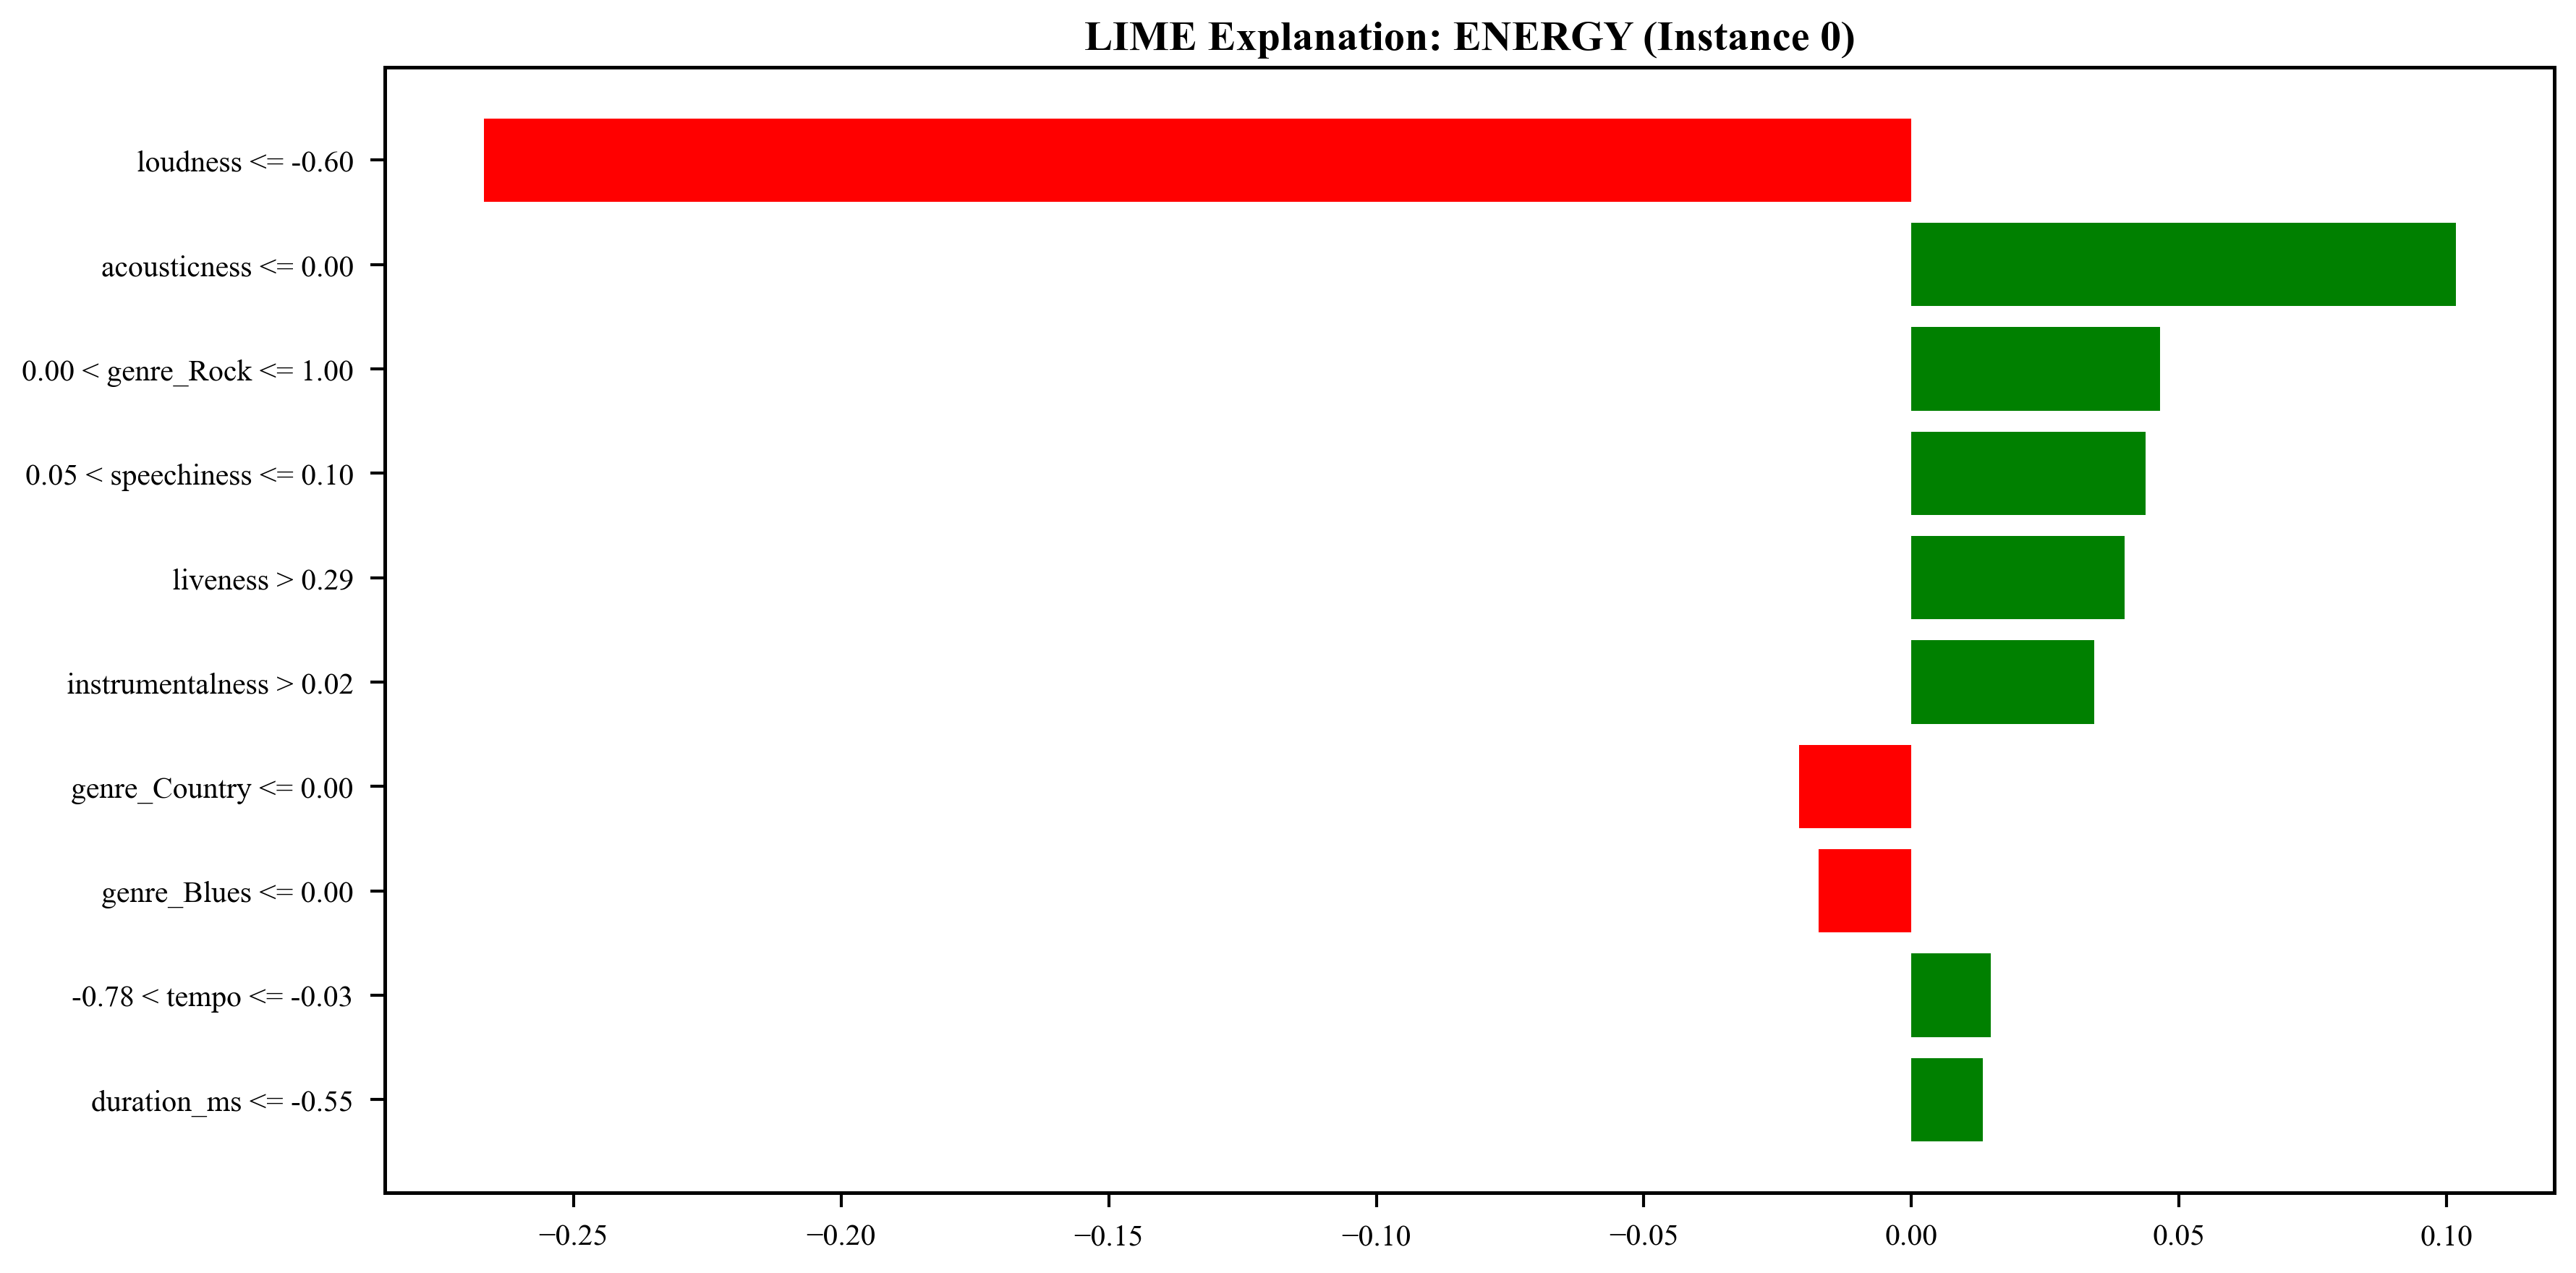


🔍 LIME for danceability...


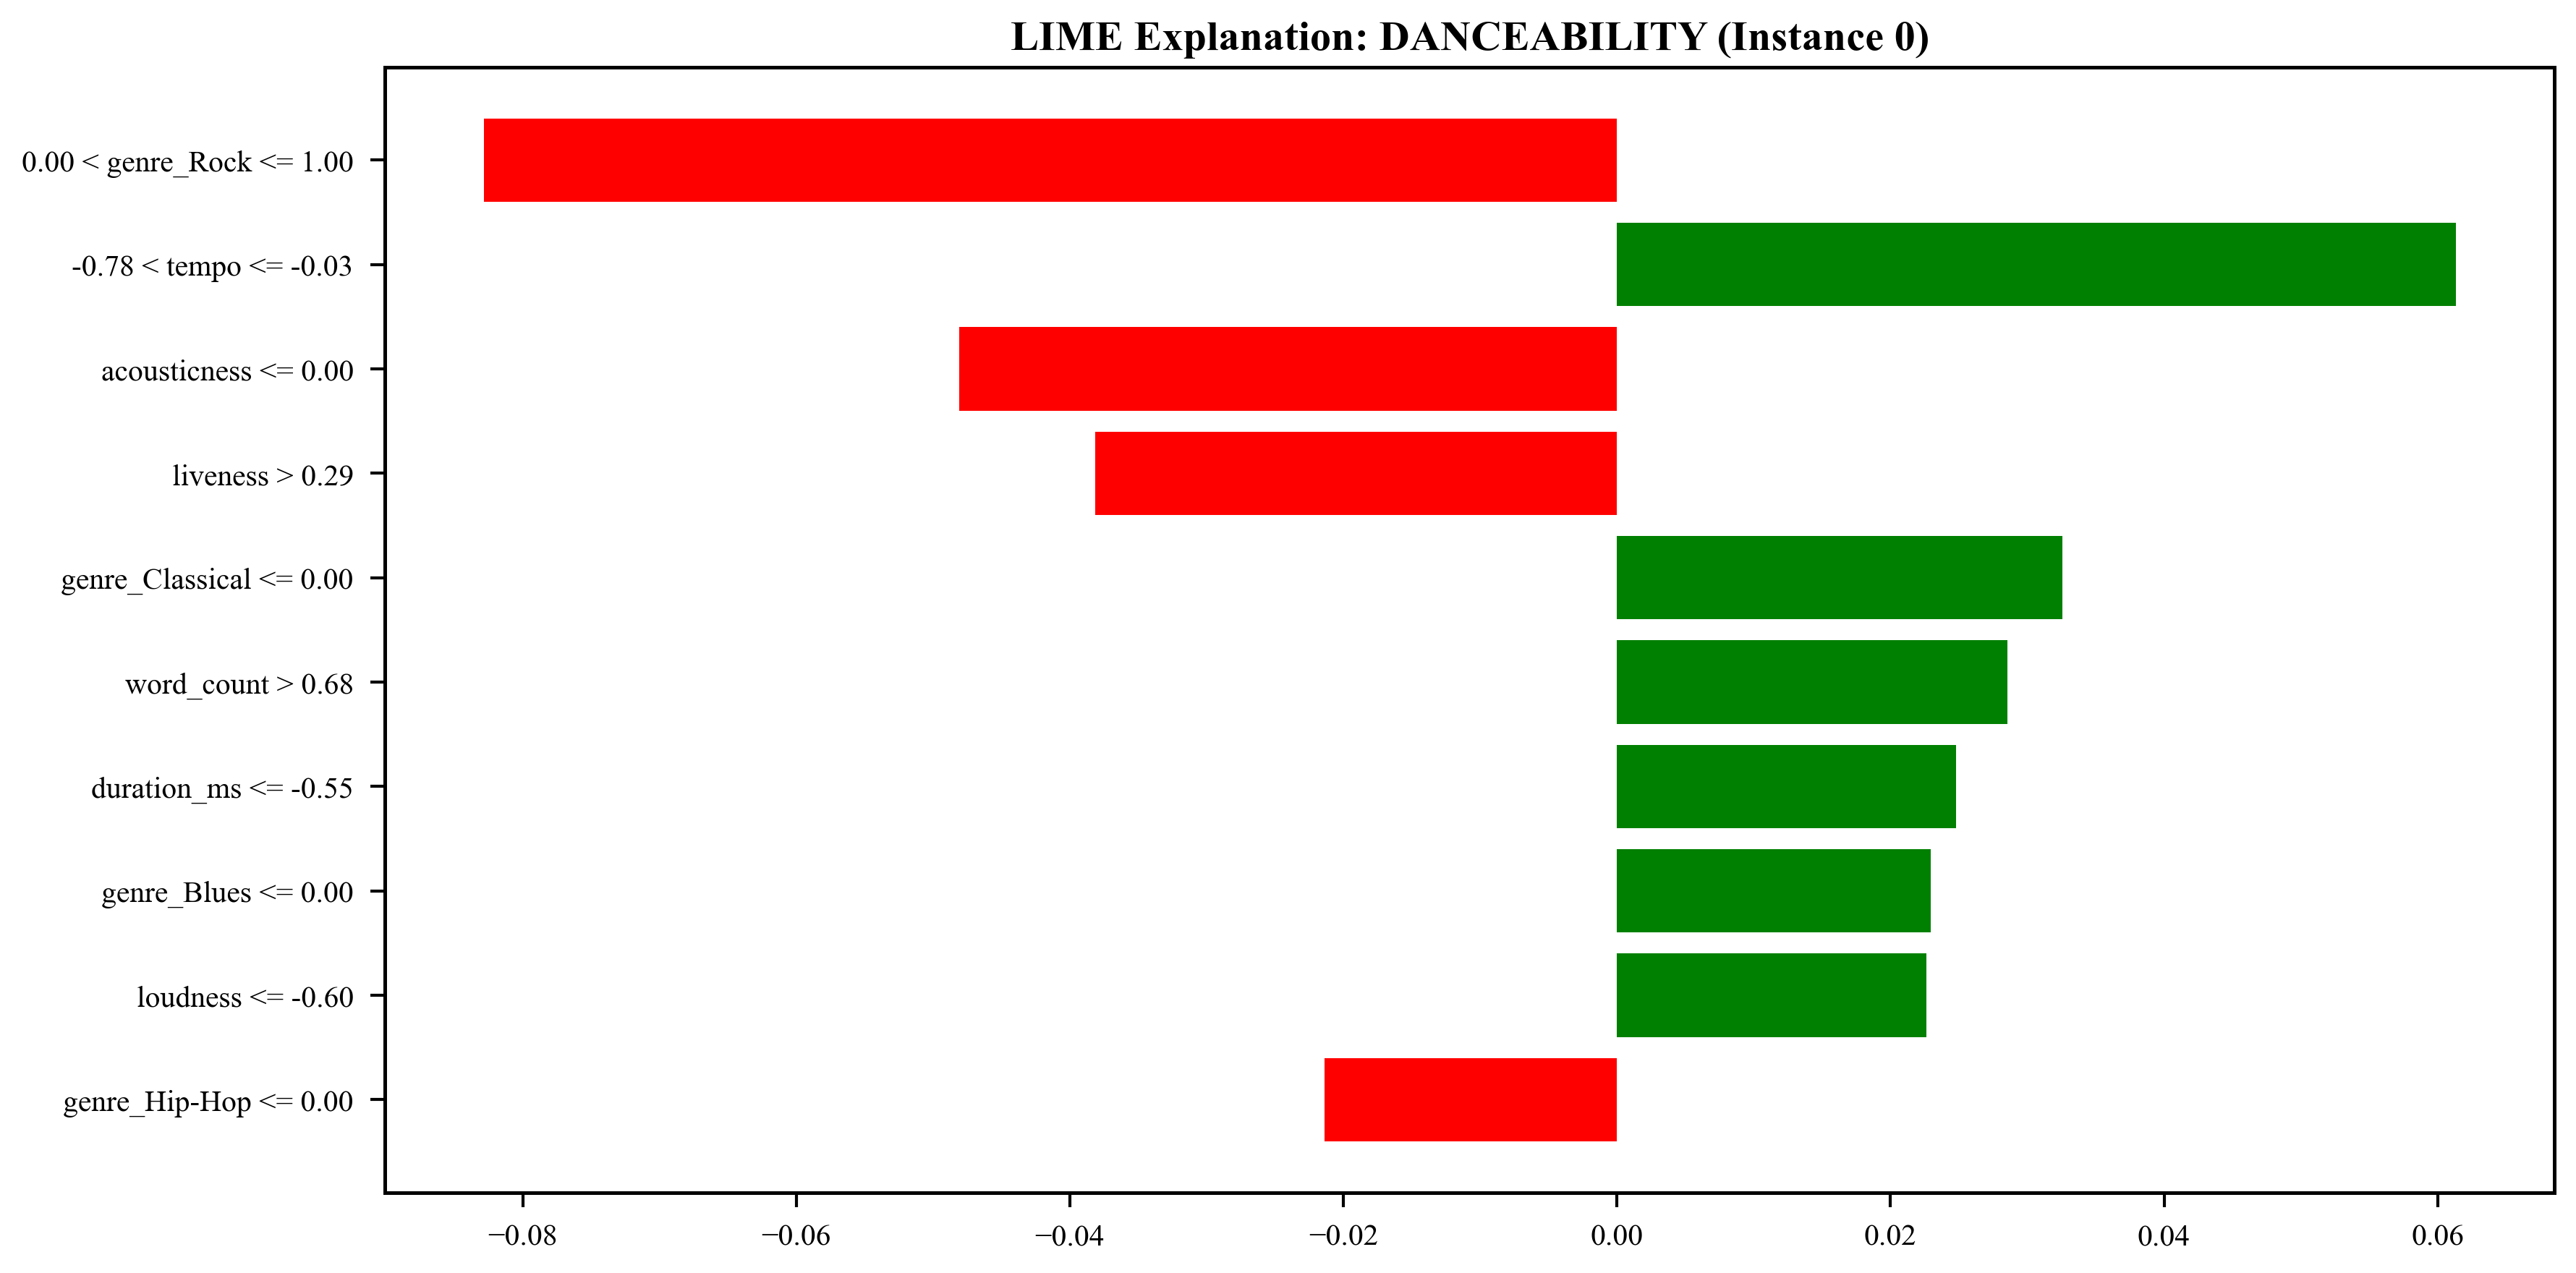


🔍 LIME for popularity...


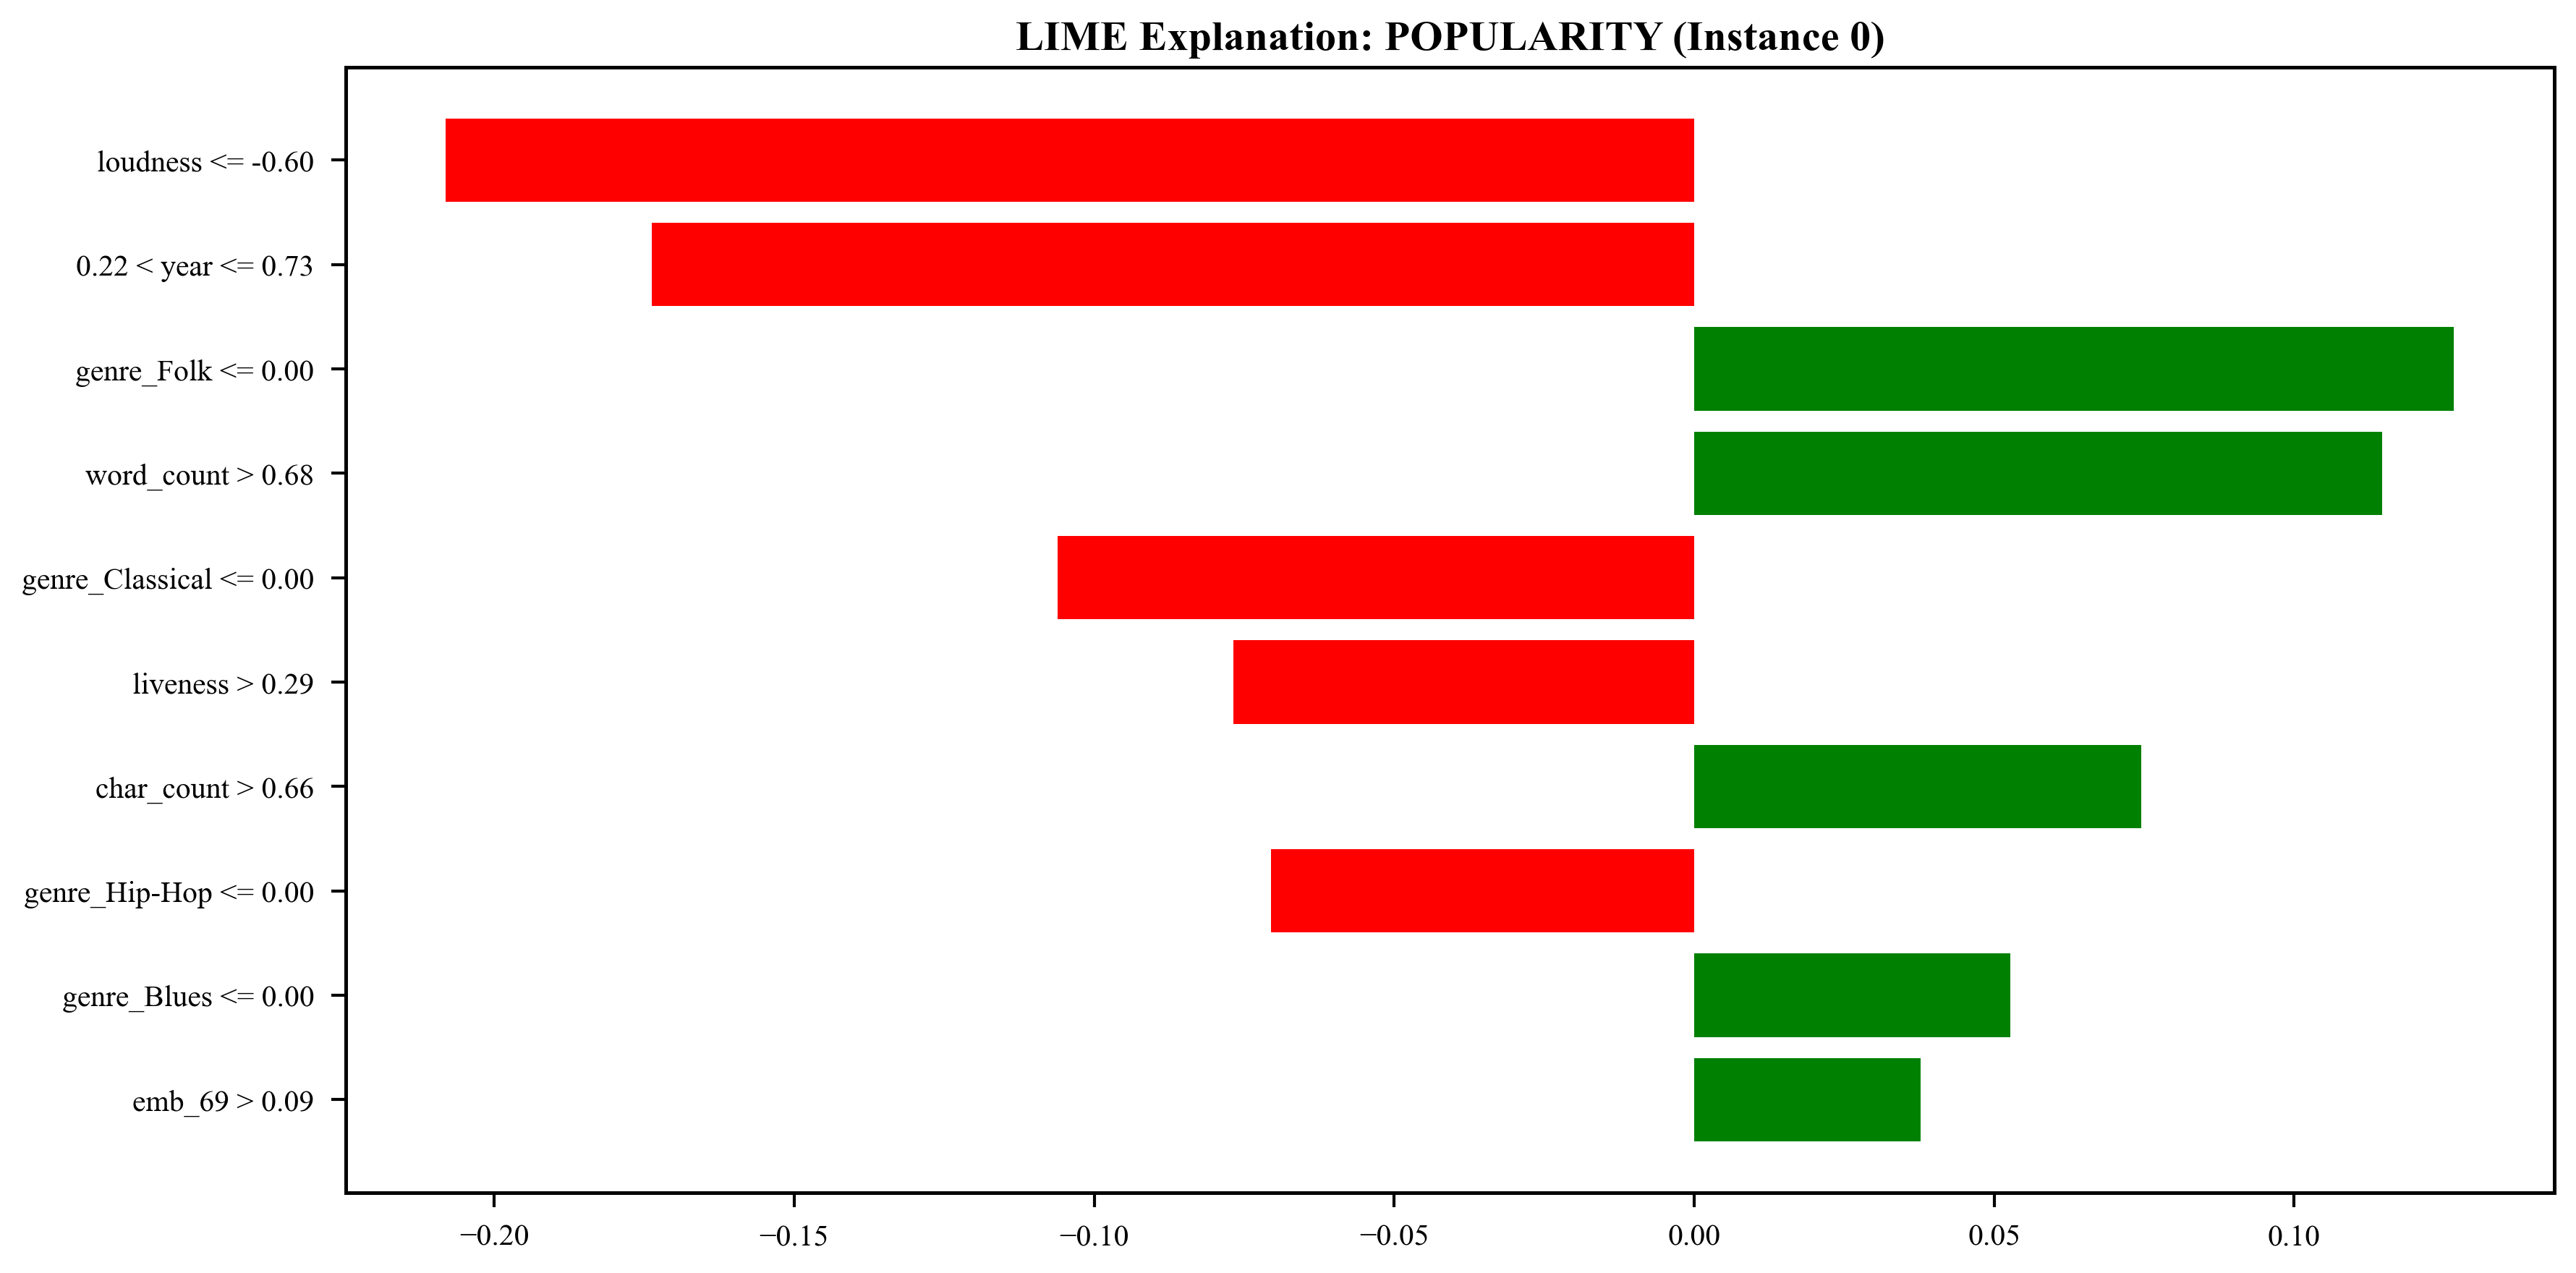

In [27]:
def run_lime_analysis(target, model_name, X_train_sample, X_test_instance, instance_idx):
    """Run LIME for a specific instance"""
    model_path = MODELS_DIR / f"{model_name}_{target}.pkl"
    model = joblib.load(model_path)
    
    # Create LIME explainer
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_sample.values,
        feature_names=X_train_sample.columns.tolist(),
        class_names=[target],
        mode='regression'
    )
    
    # Explain prediction
    exp = explainer.explain_instance(
        X_test_instance.values, 
        model.predict, 
        num_features=10
    )
    
    # Plot
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Explanation: {target.upper()} (Instance {instance_idx})", fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    fig_path = FIGURES_DIR / f"lime_{target}_instance_{instance_idx}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return exp

# Pick an instance to explain (e.g., the first one in our validation set)
instance_to_explain = X_val.iloc[0]
print(f"🧐 Explaining prediction for first instance in validation set...")

for target, model_name in TOP_MODELS.items():
    print(f"\n🔍 LIME for {target}...")
    run_lime_analysis(target, model_name, X_shap_sample, instance_to_explain, 0)

---
## 📊 Visualization 2: Feature Group Importance

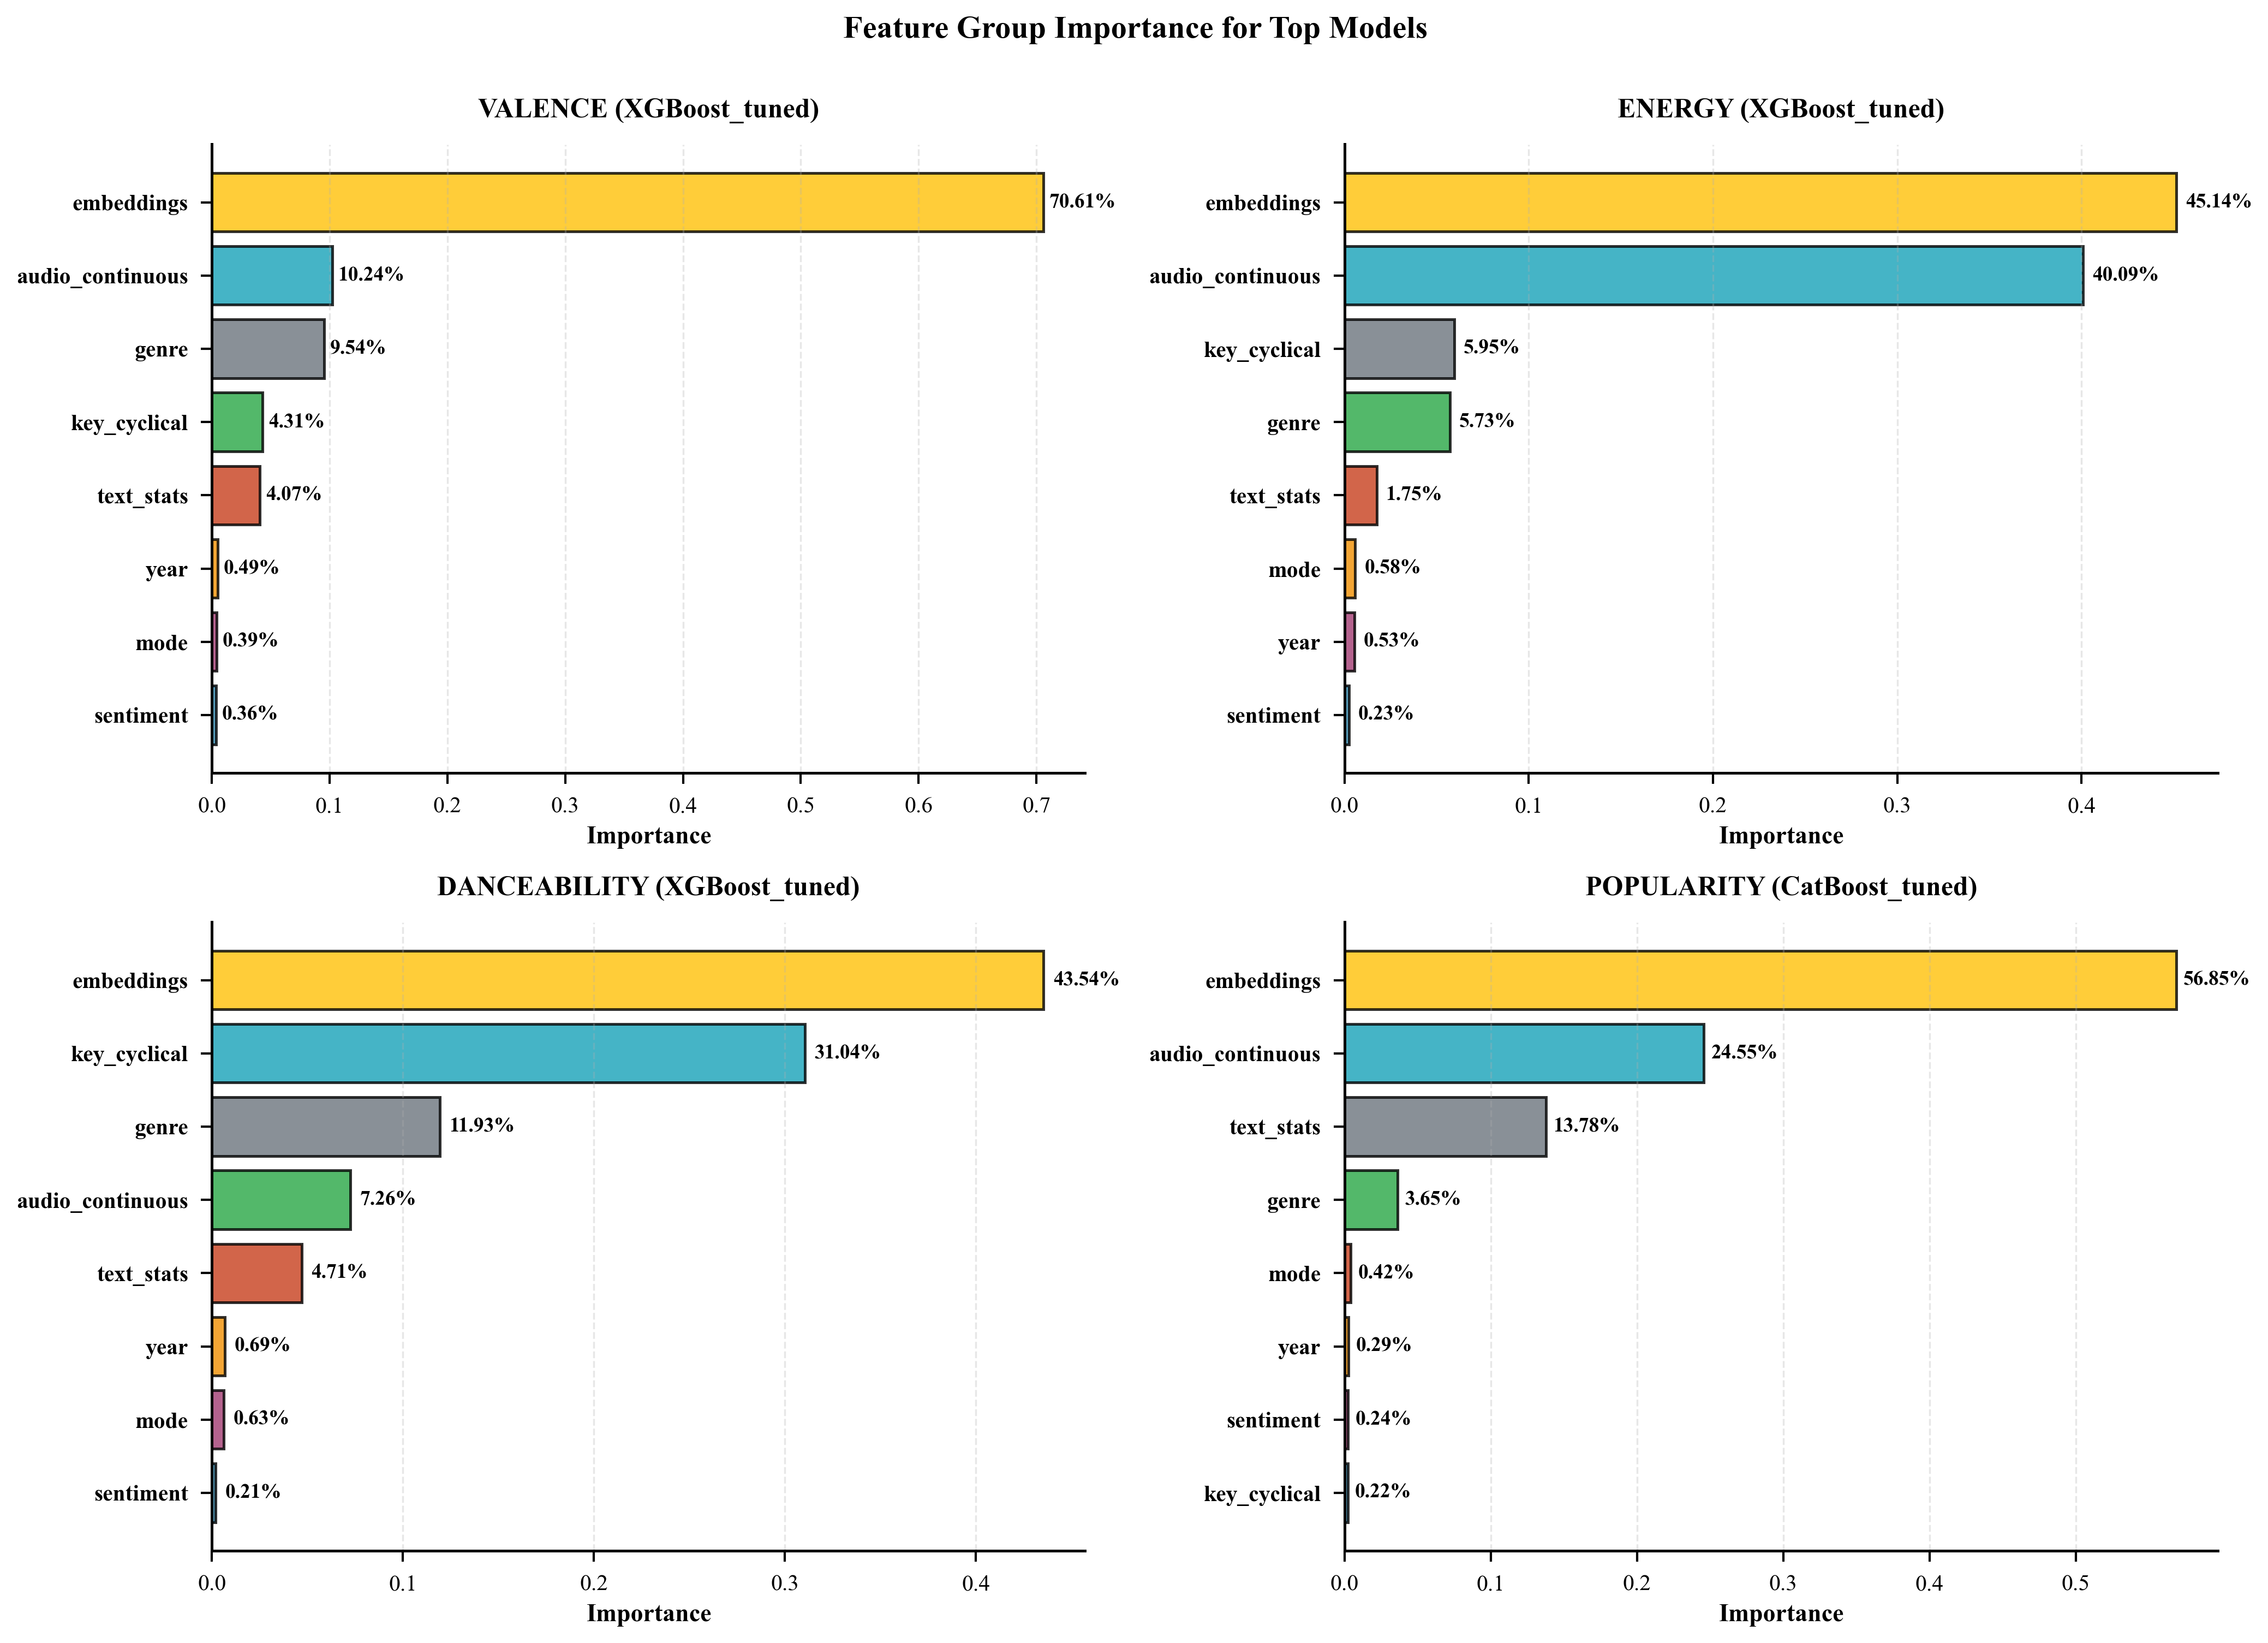

💾 Saved: feature_group_importance_top_models.png


In [28]:
def create_feature_groups():
    """Define feature groups"""
    groups = {
        'audio_continuous': list(range(0, 8)),
        'genre': list(range(8, 18)),
        'year': [18],
        'mode': [19],
        'key_cyclical': [20],
        'text_stats': list(range(21, 26)),
        'sentiment': list(range(26, 28)),
        'embeddings': list(range(28, 412)),
    }
    return groups

def aggregate_by_group(importance_df, feature_names):
    """Aggregate feature importance by group"""
    groups = create_feature_groups()
    group_importance = {}
    
    for group_name, indices in groups.items():
        group_features = [feature_names[i] for i in indices if i < len(feature_names)]
        mask = importance_df['feature'].isin(group_features)
        group_importance[group_name] = importance_df.loc[mask, 'importance'].sum()
    
    return pd.Series(group_importance).sort_values(ascending=False)

# Plot for Top Models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#28A745', '#6C757D', '#17A2B8', '#FFC107']

for ax, target in zip(axes.flatten(), TARGETS):
    model_name = TOP_MODELS[target]
    target_df = all_importance_df[(all_importance_df['target'] == target) & (all_importance_df['model'] == model_name)]
    
    if target_df.empty:
        ax.text(0.5, 0.5, f"No data for {target}", ha='center')
        continue
        
    group_imp = aggregate_by_group(target_df, feature_names)
    avg_group = group_imp.sort_values(ascending=True)
    
    bars = ax.barh(range(len(avg_group)), avg_group.values, 
                  color=colors[:len(avg_group)], edgecolor='black', alpha=0.8, linewidth=1.2)
    ax.set_yticks(range(len(avg_group)))
    ax.set_yticklabels(avg_group.index, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
    ax.set_title(f'{target.upper()} ({model_name})', fontsize=12, fontweight='bold', pad=12)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels
    for bar, val in zip(bars, avg_group.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
                f'{val:.2%}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Feature Group Importance for Top Models', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
fig_path = FIGURES_DIR / "feature_group_importance_top_models.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"💾 Saved: {fig_path.name}")

---
## 🔑 Key Insights: Embedding Contribution

In [29]:
print("🔑 EMBEDDING CONTRIBUTION ANALYSIS\n")
print("="*70)

embedding_cols = [f'emb_{i}' for i in range(384)]

insights = []
for target in TARGETS:
    target_df = all_importance_df[all_importance_df['target'] == target]
    emb_importance = target_df[target_df['feature'].isin(embedding_cols)]['importance'].sum()
    total_importance = target_df['importance'].sum()
    emb_pct = (emb_importance / total_importance * 100) if total_importance > 0 else 0
    
    print(f"   {target.upper():15s} → Embeddings: {emb_pct:5.1f}% of total importance")
    insights.append({'target': target, 'embedding_contribution_pct': emb_pct})

insights_df = pd.DataFrame(insights)
display(insights_df.style.format({'embedding_contribution_pct': '{:.2f}%'}).background_gradient(
    subset=['embedding_contribution_pct'], cmap='YlOrRd'
))

🔑 EMBEDDING CONTRIBUTION ANALYSIS

   VALENCE         → Embeddings:  70.6% of total importance
   ENERGY          → Embeddings:  45.1% of total importance
   DANCEABILITY    → Embeddings:  43.5% of total importance
   POPULARITY      → Embeddings:  56.9% of total importance


,target,embedding_contribution_pct
0,valence,70.61%
1,energy,45.14%
2,danceability,43.54%
3,popularity,56.85%


---
## ✅ Summary

In [30]:
print("\n" + "="*70)
print("✅ FEATURE IMPORTANCE & XAI ANALYSIS COMPLETE")
print("="*70)
print(f"📊 Top models analyzed: {len(TOP_MODELS)}")
print(f"🧠 XAI methods used: SHAP (Global), LIME (Local)")
print(f"📁 Results saved to: {RESULTS_DIR}")
print(f"🖼️ Figures saved to: {FIGURES_DIR}")
print("\n🎯 Next Steps:")
print("   1. Review SHAP summary plots to understand feature directionality")
print("   2. Examine LIME explanations for specific song predictions")
print("   3. Use these insights to justify model performance in the thesis")


✅ FEATURE IMPORTANCE & XAI ANALYSIS COMPLETE
📊 Top models analyzed: 4
🧠 XAI methods used: SHAP (Global), LIME (Local)
📁 Results saved to: /home/esstee/documents/bitirme/results/metrics
🖼️ Figures saved to: /home/esstee/documents/bitirme/results/figures

🎯 Next Steps:
   1. Review SHAP summary plots to understand feature directionality
   2. Examine LIME explanations for specific song predictions
   3. Use these insights to justify model performance in the thesis
